# **AWS Cloud Practitioner — Security Services**

## 1. AWS Security




AWS Security protects cloud infrastructure, applications, identities, and data.

### Shared Responsibility Model

Security is shared between AWS and the customer.

| AWS Responsibility | Customer Responsibility |
|---|---|
| Physical data centers | IAM permissions |
| Physical servers | Application security |
| AWS networking infrastructure | Data protection |
| Hypervisor infrastructure | Security group configuration |
| Managed service infrastructure | EC2 operating system patching |

AWS = Security OF the Cloud.

Customer = Security IN the Cloud.

### Main Security Principles

1. Least Privilege: Grant only necessary permissions.
2. MFA: Add another authentication factor.
3. Encryption at Rest: Protect stored data.
4. Encryption in Transit: Protect data during transmission.
5. Monitoring: Detect suspicious activities.
6. Auditing: Track actions and configuration changes.

### Important AWS Security Services

| Service | Purpose |
|---|---|
| IAM | Control access to AWS resources |
| WAF | Protect web applications |
| Shield | Protect against DDoS attacks |
| Secrets Manager | Store and rotate secrets |
| KMS | Manage encryption keys |
| GuardDuty | Detect malicious activities |
| Cognito | Authenticate application users |
| CloudTrail | Record AWS API activity |
| AWS Config | Track resource configurations |
| Security Hub | Centralize security findings |
| Inspector | Identify software vulnerabilities |
| Macie | Discover sensitive data in S3 |

### Cloud Practitioner Exam

Remember:

Security OF the Cloud = AWS.

Security IN the Cloud = Customer.

The division of responsibility depends on the AWS service being used.

---


## 2. AWS WAF




AWS WAF = Web Application Firewall.

It protects web applications against malicious HTTP and HTTPS requests.

Operates at:

Layer 7 — Application Layer.


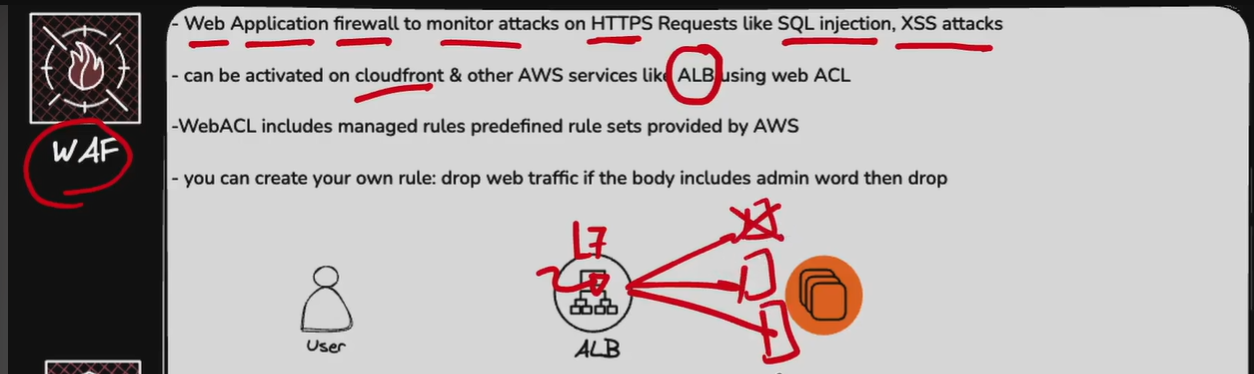

### Main Protections

- SQL Injection (SQLi)
- Cross-Site Scripting (XSS)
- Malicious IP addresses
- Excessive requests
- Unwanted bot traffic

### Supported AWS Resources

Common examples:

- Amazon CloudFront
- Application Load Balancer (ALB)
- API Gateway REST API
- Amazon Cognito User Pool

### How It Works

```text
Internet
   |
   v
AWS WAF
   |
   |-- Malicious Request --> BLOCK
   |
   |-- Valid Request ------> ALLOW
                                |
                                v
                         Web Application
```

### Web ACL

Web ACL = Web Access Control List.

It contains rules that control incoming web requests.

Possible actions include:

- Allow
- Block
- Count
- CAPTCHA
- Challenge

Example:

Block requests originating from a specified IP address.

### Rate-Based Rules

Limit requests from sources that exceed a defined request rate.

Example:

An IP address sends too many requests to a login endpoint.

WAF can block or challenge those requests.

### Cloud Practitioner Exam

WAF = Web Application Protection.

WAF protects Layer 7 HTTP/HTTPS traffic.

WAF is not the same as a VPC Network ACL.

---


## 3. AWS Shield




AWS Shield protects AWS applications against Distributed Denial of Service (DDoS) attacks.

A DDoS attack occurs when many systems flood a target with traffic to make it unavailable.


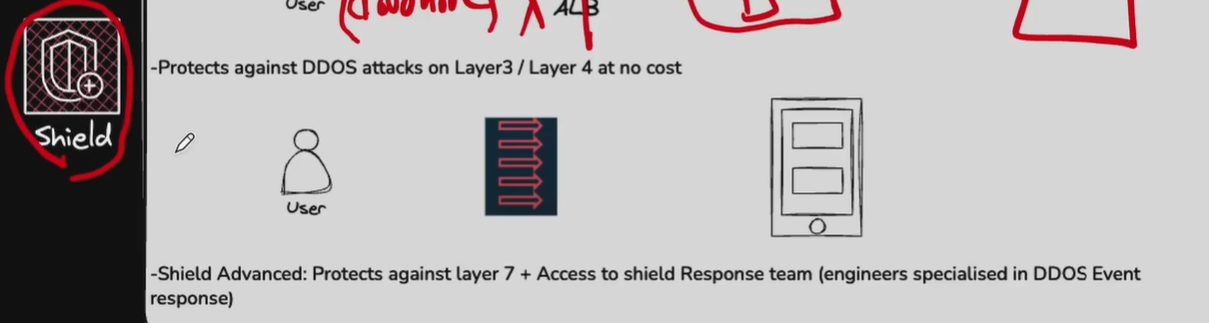

### AWS Shield Standard

- Enabled automatically for AWS customers.
- No additional charge.
- Protects against common network and transport-layer DDoS attacks.

Examples:

- UDP floods
- TCP SYN floods

### AWS Shield Advanced

Paid subscription offering enhanced DDoS protection.

Includes:

- Additional DDoS detection and mitigation
- Application-layer DDoS protection
- Advanced attack visibility
- Shield Response Team (SRT) support
- DDoS cost protection for eligible resources

### Example

Normal Traffic:

```text
Users --> CloudFront --> ALB --> EC2
```

DDoS Attack:

```text
Attackers --> Huge Traffic --> AWS Shield
                                  |
                                  v
                           Attack Mitigation
                                  |
                                  v
                           Application
```

### WAF vs Shield

| WAF | Shield |
|---|---|
| Web application firewall | DDoS protection |
| HTTP/HTTPS inspection | Traffic flood protection |
| SQL injection and XSS | Network and application DDoS |
| Custom filtering rules | Managed DDoS mitigation |

### Cloud Practitioner Exam

DDoS Protection = AWS Shield.

Web Application Firewall = AWS WAF.

Standard = Automatic protection.

Advanced = Paid enhanced protection.

---


## 4. Data Encryption



Data encryption protects information by converting it into unreadable text that can only be accessed with the appropriate decryption key.


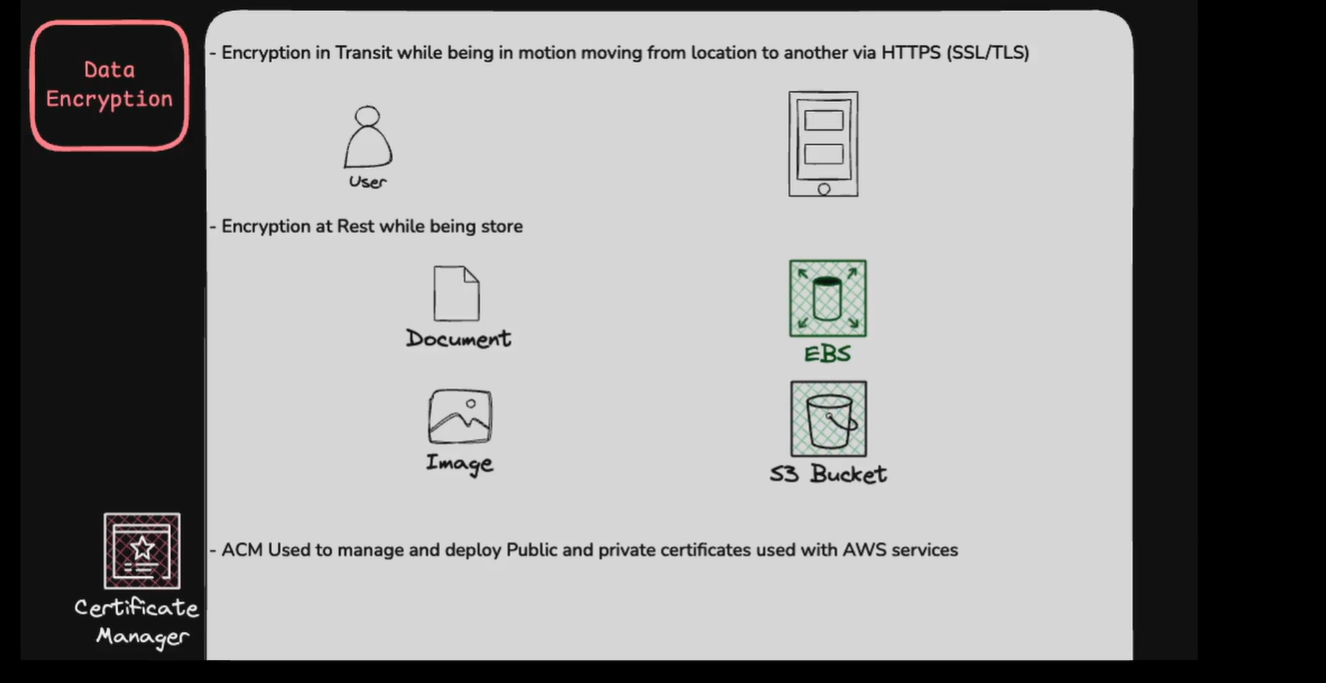

AWS supports two main types of encryption:

### 4.1 Encryption in Transit

Protects data while moving between users, applications, and AWS services.

- Uses HTTPS with TLS (formerly SSL).
- Prevents unauthorized parties from reading data during transmission.
- Example: User → HTTPS → Application Load Balancer → Web Application.

### 4.2 Encryption at Rest

Protects data while stored on AWS resources.

Examples:

| AWS Service | Encryption |
|---|---|
| Amazon S3 | Encrypts stored objects |
| Amazon EBS | Encrypts EC2 volumes and snapshots |
| Amazon RDS | Encrypts database storage |

### 4.3 AWS Certificate Manager (ACM)

**AWS Certificate Manager (ACM)** provisions, manages, and deploys public and private TLS certificates for supported AWS services.

Example:

```text
User
  |
  | HTTPS / TLS
  v
Application Load Balancer
  |
  | ACM Certificate
  v
Web Application
```

ACM certificates are commonly used with:

- Application Load Balancer
- Amazon CloudFront
- Amazon API Gateway

### 4.4 AWS Key Management Service (KMS)

**AWS KMS** creates and manages encryption keys used to protect data across AWS services.

Examples include S3, EBS, and RDS encryption.

**Remember:**

- Encryption in Transit → HTTPS / TLS
- Encryption at Rest → S3, EBS, RDS
- ACM → TLS certificate management
- KMS → Encryption key management

## 5. AWS Secrets Manager




AWS Secrets Manager securely stores and manages sensitive application credentials.

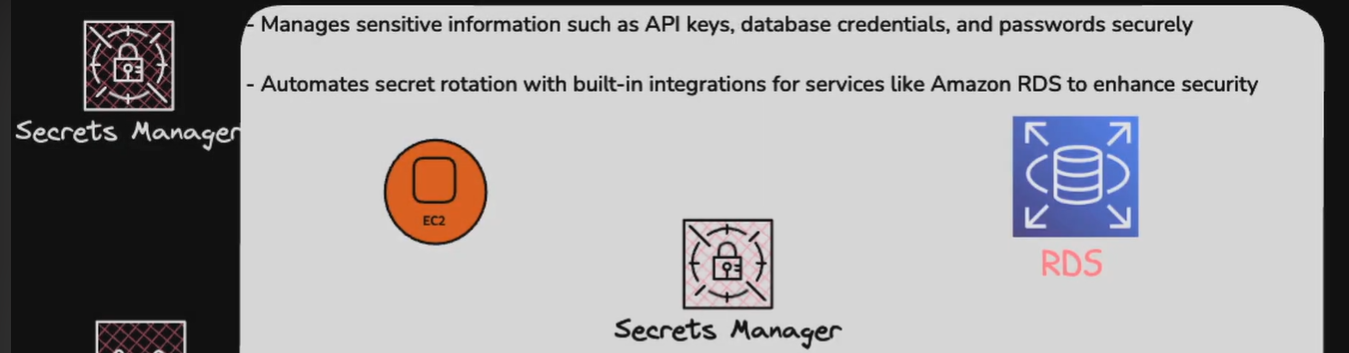

### Examples of Secrets

- Database passwords
- API keys
- Authentication tokens
- Application credentials

### Main Features

1. Secure secret storage.
2. Encryption using AWS KMS.
3. Access control using IAM.
4. Automatic secret rotation.
5. Integration with AWS applications.

### Practical Example

An application running on EC2 needs to connect to Amazon RDS.

Without Secrets Manager:

```text
EC2 Application
      |
      v
Hardcoded Database Password
      |
      v
Amazon RDS
```

With Secrets Manager:

```text
EC2 Application
      |
      v
IAM Role
      |
      v
Secrets Manager
      |
      v
Retrieve Database Credentials
      |
      v
Amazon RDS
```

The application retrieves credentials securely instead of storing them directly in source code.

### Automatic Rotation

Secrets Manager can periodically change supported credentials.

Example:

```text
Old Database Password
        |
        v
Secrets Manager Rotation
        |
        v
New Database Password
```

The stored secret and target database credentials are updated together.

### Secrets Manager vs KMS

| Secrets Manager | KMS |
|---|---|
| Stores sensitive credentials | Manages encryption keys |
| Rotates secrets | Performs key-related cryptographic operations |
| Retrieves application secrets | Supports data encryption |

### Cloud Practitioner Exam

Store and rotate database passwords = Secrets Manager.

Manage encryption keys = KMS.

---


## 6. AWS KMS




KMS = Key Management Service.

AWS KMS manages cryptographic keys used to encrypt and decrypt data.


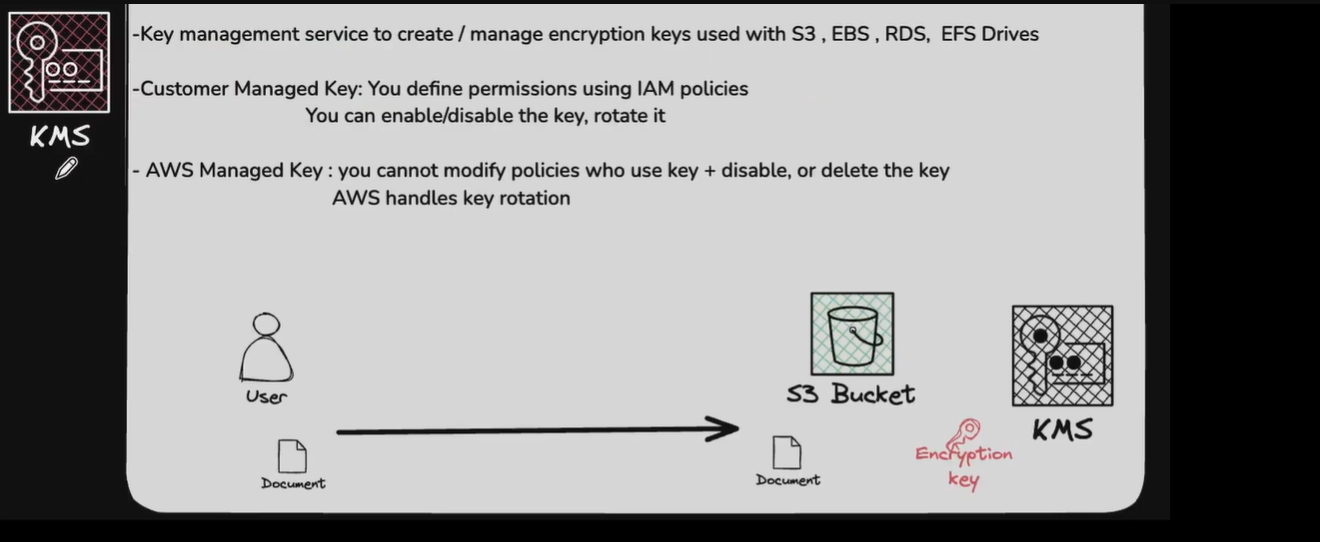

### Main Features

- Create encryption keys.
- Manage encryption keys.
- Control key access.
- Support key rotation.
- Integrate with AWS services.
- Audit key usage with CloudTrail.

### Common Integrations

- Amazon S3
- Amazon EBS
- Amazon RDS
- AWS Secrets Manager

### How It Works

```text
Application Data
      |
      v
Encryption using a Data Key
      |
      v
Encrypted Data

AWS KMS protects the data key using a KMS key.
```

This approach is called envelope encryption.

### KMS Key Types

| Key Type | Managed By |
|---|---|
| AWS owned key | AWS service |
| AWS managed key | AWS |
| Customer managed key | Customer |

Customer managed keys provide greater control over permissions and lifecycle management.

### Practical Example

Encrypting an S3 object:

```text
User uploads a file.
      |
      v
Amazon S3
      |
      v
AWS KMS
      |
      v
Encrypted Object Stored in S3
```

### Cloud Practitioner Exam

KMS = Encryption Key Management.

Secrets Manager = Secrets Storage.

CloudHSM = Dedicated hardware security modules for customers requiring greater control over cryptographic hardware.

---


## 7. Amazon GuardDuty




Amazon GuardDuty is a managed threat detection service.

It continuously monitors AWS environments to identify suspicious and malicious activities.

### Detection Technologies

GuardDuty uses:

- Machine Learning
- Anomaly Detection
- Threat Intelligence

### Important Data Sources

- AWS CloudTrail management events
- VPC Flow Logs
- Route 53 Resolver DNS query logs

Additional protection plans support services such as S3, EC2, EKS, RDS, and Lambda.

### What Can GuardDuty Detect?

Examples:

- Compromised IAM credentials
- Suspicious API calls
- Cryptocurrency mining
- Communication with malicious IP addresses
- Potential data exfiltration
- Malware-related activity

### Practical Example

An EC2 instance communicates with a known malicious server.

```text
EC2 Instance
      |
      v
Suspicious Network Activity
      |
      v
GuardDuty
      |
      v
Security Finding
      |
      v
Amazon EventBridge
      |
      v
Notification / Automated Response
```

### Important Note

GuardDuty primarily detects threats and generates findings.

It does not replace WAF or Shield.

Automated remediation can be implemented through integrations such as EventBridge and Lambda.

### Cloud Practitioner Exam

GuardDuty = Intelligent Threat Detection.

CloudTrail = AWS API Activity History.

AWS Config = Resource Configuration Tracking.

Inspector = Software Vulnerability Management.

---


## 8. Amazon Cognito




Amazon Cognito provides authentication and authorization for web and mobile applications.

It helps applications manage customer identities.

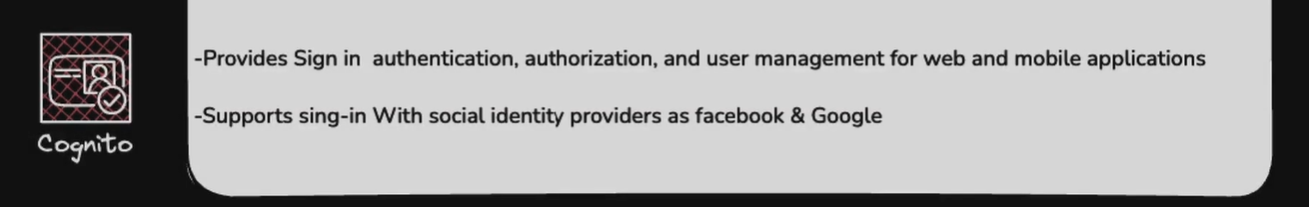

### Main Features

- User registration
- User login
- Password recovery
- Multi-Factor Authentication (MFA)
- Social login
- User management
- JWT-based authentication

### Two Main Components

#### 1. User Pools

Used for application user authentication.

Example:

```text
User
 |
 v
Login Page
 |
 v
Cognito User Pool
 |
 v
Authentication
 |
 v
JWT Tokens
 |
 v
Application Access
```

A User Pool manages application users and issues authentication tokens.

#### 2. Identity Pools

Used to provide temporary AWS credentials.

Example:

```text
Authenticated User
       |
       v
Cognito Identity Pool
       |
       v
Temporary AWS Credentials
       |
       v
Amazon S3 / DynamoDB
```

Identity Pools use IAM roles to control AWS resource access.

### User Pools vs Identity Pools

| User Pools | Identity Pools |
|---|---|
| Authenticate users | Grant AWS resource access |
| Manage user directory | Provide temporary AWS credentials |
| Issue JWT tokens | Use IAM roles |
| Sign-up and sign-in | Access S3 and other AWS services |

### Cognito vs IAM

| Cognito | IAM |
|---|---|
| Application users | AWS identities and workloads |
| Customer authentication | AWS resource permissions |
| Login and registration | Policies and roles |

### Cloud Practitioner Exam

Web/Mobile User Authentication = Cognito User Pools.

Temporary AWS Credentials for App Users = Cognito Identity Pools.

AWS Resource Access Management = IAM.

---


## 9. Amazon Macie



**Amazon Macie** is a data security service that uses machine learning and pattern matching to discover and protect sensitive data stored in Amazon S3.

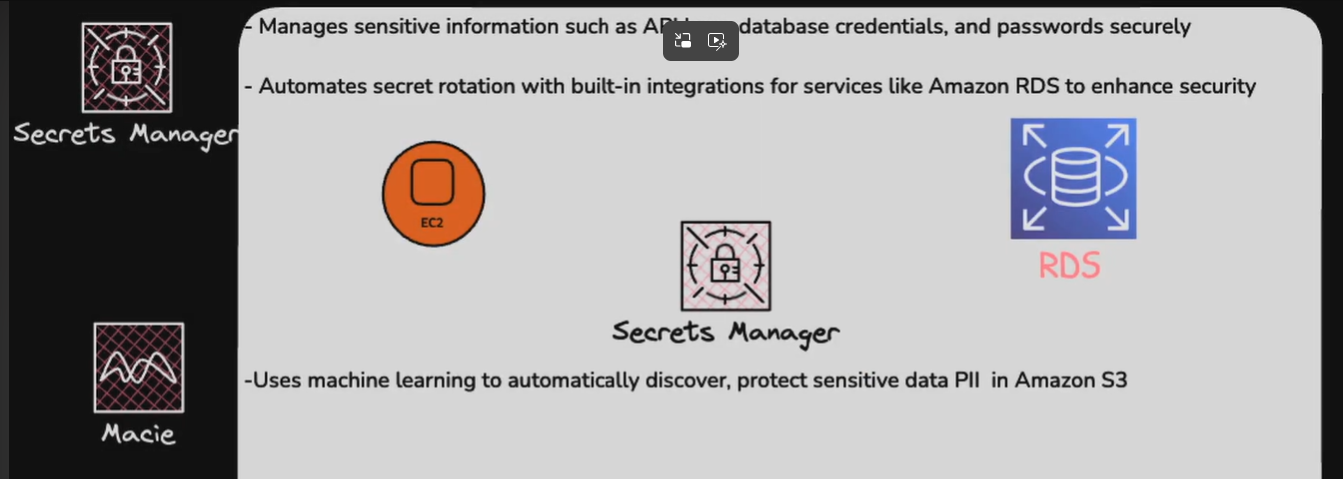


### Key Features
- Automatically discovers sensitive data, such as Personally Identifiable Information (PII).
- Detects information such as names, credit card numbers, and credentials.
- Monitors S3 buckets for security and access risks.
- Generates findings to help identify potential data exposure.

### Example

An S3 bucket contains documents with customer credit card numbers.

```text
Amazon S3
    |
    v
Amazon Macie
    |
    v
Discover Sensitive Data
    |
    v
Generate Security Finding


## 10. AWS Artifact




AWS Artifact is a self-service portal that provides on-demand access to AWS compliance reports, certifications, and agreements.

It helps organizations demonstrate compliance with security and regulatory requirements.

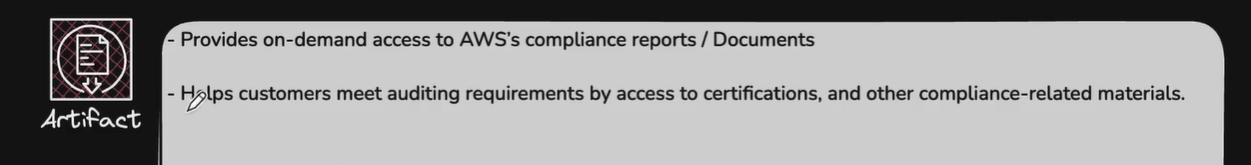

### Main Features

- Access AWS compliance reports.
- Download security and audit documents.
- Access reports related to standards such as ISO and SOC.
- Review AWS compliance certifications.
- Manage supported compliance agreements.
- Support internal and external auditing requirements.

### Practical Example

A company uses AWS to store customer information.

During an external security audit, the auditor requests evidence of AWS's compliance with recognized security standards.

The company can obtain the relevant AWS reports through Artifact.

```text
Company
   |
   v
External Security Audit
   |
   v
AWS Artifact
   |
   v
Compliance Reports
   |
   v
Auditor Reviews Documents
```

### AWS Artifact vs AWS Config

| AWS Artifact | AWS Config |
|---|---|
| Provides AWS compliance documentation | Records AWS resource configurations |
| Accesses certifications and reports | Evaluates resources against configuration rules |
| Supports compliance audits | Supports configuration compliance monitoring |
| AWS compliance evidence | Customer resource configuration evidence |

### Cloud Practitioner Exam

AWS Compliance Reports = AWS Artifact.

AWS Certifications and Audit Documents = AWS Artifact.

AWS Resource Configuration Compliance = AWS Config.

---


## 11. Amazon GuardDuty




Amazon GuardDuty is a continuous threat detection service that identifies suspicious or malicious activity in AWS accounts and workloads.

It analyzes AWS security signals using threat intelligence, machine learning, and anomaly detection.

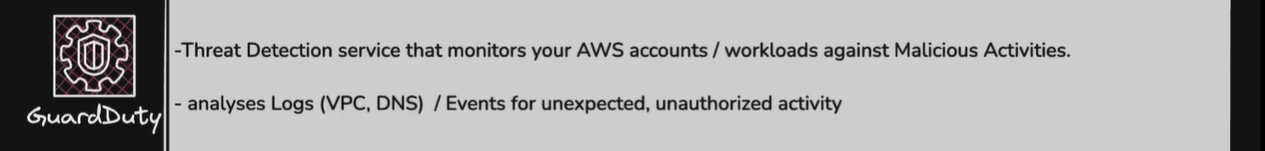

### Main Features

- Continuous threat detection.
- Detect suspicious AWS API activity.
- Identify potentially compromised credentials.
- Detect unusual network connections.
- Identify communication with known malicious destinations.
- Generate prioritized security findings.
- Integrate with Amazon EventBridge for automated responses.

### Data Sources

GuardDuty analyzes signals from sources such as:

- AWS CloudTrail management events
- VPC Flow Logs
- DNS activity

Additional protection plans can analyze supported services and workloads, including S3, EKS, EC2 runtime activity, and others.

### Practical Example

An EC2 instance begins communicating with a suspicious external IP address.

GuardDuty identifies the unusual behavior and generates a security finding.

```text
EC2 Instance
     |
     v
Suspicious Network Activity
     |
     v
VPC Flow Logs / DNS Signals
     |
     v
Amazon GuardDuty
     |
     v
Threat Detection
     |
     v
Security Finding
     |
     v
Security Team
```

### Automated Security Response

GuardDuty can integrate with EventBridge to trigger a response.

Example:

```text
Amazon GuardDuty
       |
       v
Security Finding
       |
       v
Amazon EventBridge
       |
       v
AWS Lambda
       |
       v
Security Response
```

An authorized Lambda function could update a security group or notify the security team, depending on the organization's response policy.

GuardDuty detects threats; it does not automatically remediate every finding.

### Amazon GuardDuty vs CloudTrail

| Amazon GuardDuty | AWS CloudTrail |
|---|---|
| Detects suspicious activity | Records AWS API activity |
| Generates threat findings | Provides event history |
| Uses threat intelligence and analytics | Records who performed actions and when |
| Threat detection | Auditing and investigation |

### Cloud Practitioner Exam

Continuous Threat Detection = GuardDuty.

Suspicious API Calls = GuardDuty.

Compromised Credentials Detection = GuardDuty.

AWS API Activity History = CloudTrail.

---


## 12. Amazon Inspector




Amazon Inspector is an automated vulnerability management service that continuously assesses supported AWS workloads for software vulnerabilities and unintended network exposure.

It helps security teams identify weaknesses before attackers exploit them.


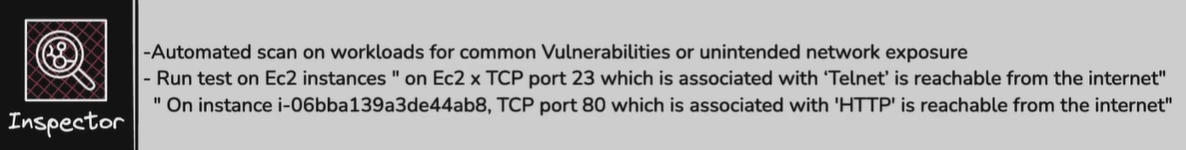

### Main Features

- Automated vulnerability scanning.
- Detect known software vulnerabilities (CVEs).
- Assess supported EC2 instances.
- Scan supported Amazon ECR container images.
- Assess supported AWS Lambda functions.
- Identify unintended EC2 network exposure.
- Prioritize findings according to risk and context.

### Supported Workloads

| AWS Service | What Inspector Examines |
|---|---|
| Amazon EC2 | Supported software packages and network exposure |
| Amazon ECR | Container image vulnerabilities |
| AWS Lambda | Supported function package and code vulnerabilities |

Available scanning capabilities depend on the resource and enabled Inspector scanning features.

### Practical Example 1 — EC2 Vulnerability

An EC2 instance has an outdated software package containing a known security vulnerability.

Inspector identifies the issue and creates a finding.

```text
EC2 Instance
     |
     v
Installed Software
     |
     v
Amazon Inspector
     |
     v
Vulnerability Assessment
     |
     v
Known Vulnerability Found
     |
     v
Security Finding
     |
     v
Update Software Package
```

### Practical Example 2 — Network Exposure

An EC2 instance has a network configuration that makes an unintended port reachable from the internet.

Inspector can identify relevant network exposure findings.

```text
EC2 Instance
     |
     v
Network Configuration
     |
     v
Amazon Inspector
     |
     v
Network Reachability Assessment
     |
     v
Potential Exposure Finding
     |
     v
Review Security Configuration
```

Inspector identifies vulnerabilities and exposure; remediation generally requires a separate action.

### Amazon Inspector vs GuardDuty

| Amazon Inspector | Amazon GuardDuty |
|---|---|
| Finds vulnerabilities | Detects suspicious activity |
| Assesses software and network exposure | Analyzes security signals |
| Identifies known CVEs | Identifies potential threats |
| Helps prevent exploitation through remediation | Helps detect potential compromises |

### Cloud Practitioner Exam

Software Vulnerability Scanning = Inspector.

EC2 Vulnerability Assessment = Inspector.

ECR Container Image Scanning = Inspector.

Suspicious or Malicious Activity = GuardDuty.

---


## 13. Amazon Detective




Amazon Detective helps security teams investigate suspicious activity and identify potential root causes of security incidents.

It analyzes and correlates security-related information to help investigators understand relationships between AWS resources, identities, and events.

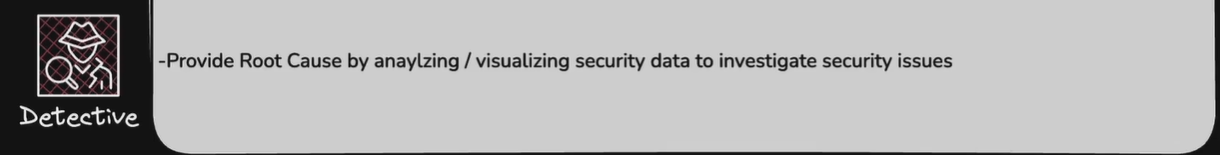

### Main Features

- Security investigation.
- Root-cause analysis.
- Visualize security-related activity.
- Investigate suspicious resource behavior.
- Analyze relationships between AWS resources and identities.
- Explore historical activity associated with security findings.
- Integrate with Amazon GuardDuty findings.

### Practical Example

GuardDuty detects suspicious activity involving an EC2 instance.

The security team needs to understand:

- Which EC2 instance was involved?
- Which IP addresses communicated with it?
- What related security activity occurred?
- Which AWS identities or resources may be associated with the incident?

Amazon Detective helps investigators examine the relevant activity and relationships.

```text
EC2 Instance
     |
     v
Suspicious Activity
     |
     v
Amazon GuardDuty
     |
     v
Security Finding
     |
     v
Amazon Detective
     |
     v
Analyze Related Activity
     |
     v
Investigate Potential Root Cause
```

### GuardDuty and Detective Together

```text
Amazon GuardDuty
       |
       v
Detect a Potential Threat
       |
       v
Generate Finding
       |
       v
Amazon Detective
       |
       v
Investigate the Finding
       |
       v
Understand Related Activity
```

GuardDuty helps identify potential threats.

Detective helps investigate what happened and understand the surrounding evidence.

Detective is an investigation service, not a replacement for vulnerability scanning or preventive access controls.

### Amazon Detective vs GuardDuty vs Inspector

| Service | Main Question |
|---|---|
| Amazon GuardDuty | Is suspicious activity occurring? |
| Amazon Inspector | Does this workload have known vulnerabilities? |
| Amazon Detective | What happened, and what activity is associated with the incident? |

### Cloud Practitioner Exam

Security Investigation = Amazon Detective.

Potential Root-Cause Analysis = Amazon Detective.

Investigate GuardDuty Findings = Amazon Detective.

Threat Detection = Amazon GuardDuty.

---


##  Quick Comparison — AWS Security Services



### 5.1 Complete Security Services Comparison

| AWS Service | Main Purpose | Practical Example |
|---|---|---|
| AWS IAM | Manage AWS identities and permissions | Allow an EC2 instance to access an S3 bucket through an IAM role |
| Amazon Cognito | Authentication and authorization for application users | Allow customers to sign up and log in to a web application |
| AWS KMS | Create and manage encryption keys | Encrypt an S3 document using a customer-managed KMS key |
| AWS Certificate Manager (ACM) | Manage TLS certificates | Enable HTTPS on an Application Load Balancer |
| AWS Secrets Manager | Securely store and rotate secrets | Store and automatically rotate RDS database credentials |
| Amazon Macie | Discover sensitive data in S3 | Identify customer information and credit card numbers in S3 documents |
| AWS WAF | Filter HTTP/HTTPS requests | Block requests to `/waf-test` |
| AWS Shield Standard | Baseline DDoS protection | Protect an Application Load Balancer from common DDoS attacks |
| AWS Shield Advanced | Additional paid DDoS protection | Provide enhanced protection for critical applications |
| AWS Artifact | Access compliance documentation | Download AWS SOC and ISO compliance reports |
| Amazon GuardDuty | Detect suspicious or malicious activity | Detect unusual API calls or suspicious EC2 network activity |
| Amazon Inspector | Identify software vulnerabilities and unintended network exposure | Find a vulnerable software package on EC2 |
| Amazon Detective | Investigate security incidents | Investigate a GuardDuty finding and related resource activity |
| AWS CloudTrail | Record AWS API activity | Identify who deleted an S3 bucket |
| AWS Config | Record and evaluate resource configurations | Detect an S3 bucket that violates a security configuration rule |
| Amazon CloudWatch | Monitor metrics, logs, and alarms | Generate an alarm when application error rates increase |
| Security Groups | Control network access to resources | Allow EC2 HTTP traffic only from the ALB Security Group |
| VPC | Provide an isolated networking environment | Deploy application resources inside a dedicated VPC |
| Amazon S3 Block Public Access | Prevent unwanted public access to S3 resources | Block public access to confidential documents |

---

### 5.2 Remember — Security Services by Function

#### Identity and Access Management

```text
AWS IAM
    |
    v
AWS Identity and Resource Permissions
```

```text
Amazon Cognito
    |
    v
Application User Authentication
```

```text
Security Groups
    |
    v
Network Access Control
```

#### Data Protection and Encryption

```text
AWS KMS
    |
    v
Encryption Key Management
```

```text
AWS Certificate Manager
    |
    v
TLS Certificates / HTTPS
```

```text
AWS Secrets Manager
    |
    v
Secrets Storage and Rotation
```

```text
Amazon Macie
    |
    v
Discover Sensitive Data in S3
```

#### Application and Network Protection

```text
AWS WAF
    |
    v
Filter HTTP/HTTPS Requests
```

```text
AWS Shield
    |
    v
DDoS Protection
```

```text
Amazon VPC
    |
    v
Network Isolation
```

#### Threat Detection and Investigation

```text
Amazon GuardDuty
    |
    v
Detect Threats
```

```text
Amazon Inspector
    |
    v
Find Vulnerabilities
```

```text
Amazon Detective
    |
    v
Investigate Security Incidents
```

#### Compliance, Auditing, and Monitoring

```text
AWS Artifact
    |
    v
Compliance Reports
```

```text
AWS CloudTrail
    |
    v
AWS API Activity History
```

```text
AWS Config
    |
    v
Resource Configuration Compliance
```

```text
Amazon CloudWatch
    |
    v
Monitoring and Alarms
```

---

### 5.3 Typical AWS Security Workflow

Consider a company hosting an application on AWS.

```text
                       APPLICATION USERS
                               |
                               v
                         Amazon Cognito
                               |
                               v
                         Authentication
                               |
                               v
                       AWS Shield Standard
                               |
                               v
                            AWS WAF
                               |
                               v
                    Application Load Balancer
                               |
                               v
                         Security Group
                               |
                               v
                         EC2 Application
                               |
                  +------------+------------+
                  |                         |
                  v                         v
                 IAM                   Secrets Manager
                  |                         |
                  v                         v
          AWS Permissions           Database Credentials
                  |                         |
                  +------------+------------+
                               |
                               v
                        AWS Resources
                               |
                  +------------+------------+
                  |                         |
                  v                         v
                  S3                       RDS
                  |                         |
                  +------------+------------+
                               |
                               v
                             AWS KMS
                               |
                               v
                        Data Encryption
```

Security monitoring and investigation run alongside the application:

```text
                        AWS Resources
                              |
          +-------------------+-------------------+
          |                   |                   |
          v                   v                   v
      GuardDuty           Inspector             Macie
          |                   |                   |
          v                   v                   v
    Threat Finding      Vulnerability      Sensitive Data
                           Finding            Finding
          |                   |                   |
          +-------------------+-------------------+
                              |
                              v
                         Security Team
                              |
                              v
                        Amazon Detective
                              |
                              v
                     Security Investigation
                              |
                              v
                       Remediation Actions
```

Auditing, compliance, and monitoring:

```text
AWS CloudTrail
      |
      v
Record AWS API Activity

AWS Config
      |
      v
Evaluate Resource Configurations

Amazon CloudWatch
      |
      v
Monitor Metrics and Logs

AWS Artifact
      |
      v
Provide AWS Compliance Evidence
```

---

### 5.4 Cloud Practitioner Exam Summary

| Exam Scenario | AWS Service |
|---|---|
| Manage AWS users, roles, and policies | IAM |
| Authenticate web and mobile application users | Cognito User Pools |
| Provide temporary AWS credentials to application users | Cognito Identity Pools |
| Manage encryption keys | KMS |
| Encrypt S3 objects using a customer-managed key | KMS + S3 SSE-KMS |
| Manage HTTPS certificates | ACM |
| Store and rotate database credentials | Secrets Manager |
| Discover PII in S3 | Macie |
| Block malicious HTTP requests | WAF |
| Protect against DDoS attacks | Shield |
| Access AWS compliance reports | Artifact |
| Detect suspicious AWS activity | GuardDuty |
| Scan EC2, ECR, and Lambda for supported vulnerabilities | Inspector |
| Investigate security findings | Detective |
| Record AWS API calls | CloudTrail |
| Track resource configuration changes | Config |
| Create monitoring alarms | CloudWatch |
| Control EC2 inbound and outbound network traffic | Security Groups |
| Isolate AWS network resources | VPC |
| Prevent public access to S3 buckets | S3 Block Public Access |

### Final Exam Keywords

**IAM → AWS Access Management**

**Cognito → Application Authentication**

**KMS → Encryption Keys**

**ACM → TLS Certificates**

**Secrets Manager → Secrets and Rotation**

**Macie → Sensitive Data / PII**

**WAF → Web Application Firewall**

**Shield → DDoS Protection**

**Artifact → Compliance Reports**

**GuardDuty → Threat Detection**

**Inspector → Vulnerability Assessment**

**Detective → Security Investigation**

**CloudTrail → API Auditing**

**Config → Configuration Compliance**

**CloudWatch → Monitoring and Alarms**

**Security Groups → Network Firewall**

**VPC → Network Isolation**

# **AWS Security Practical Lab — WAF, Shield, and Security Groups**



## 1. Lab Overview

### Scenario

A company hosts a website on an Amazon EC2 instance behind an Application Load Balancer (ALB).

The company wants to:

- Control which network connections can reach the application.
- Block specific unwanted HTTP requests.
- Add managed web-application security rules.
- Understand automatic DDoS protection.
- Monitor blocked requests and security events.

We will use three security layers:

| Security Layer | AWS Service | Purpose |
|---|---|---|
| Network access | Security Groups | Control permitted inbound and outbound connections |
| Web application protection | AWS WAF | Inspect and filter HTTP/HTTPS requests |
| DDoS protection | AWS Shield Standard | Protect supported AWS resources against common DDoS attacks |

### Final Architecture

```text
                      INTERNET
                         |
                         v
                 AWS Shield Standard
                         |
                         v
                      AWS WAF
                         |
                  Allow / Block
                         |
                         v
             Application Load Balancer
                         |
                         v
                  Target Group
                         |
                         v
                EC2 Security Group
                         |
                         v
                    EC2 Instance
                         |
                         v
                  Apache Website
```

**Important:** Security Groups, AWS WAF, and AWS Shield protect different layers. They complement one another rather than replace one another.

---

## 2. Understand the Three Security Services

## 2.1 Security Groups

A Security Group is a stateful virtual firewall attached to supported AWS resources.

It controls inbound and outbound traffic based on rules.

Example:

```text
Allow TCP 80
Source: ALB Security Group
```

This allows the EC2 web server to receive HTTP traffic from the ALB.

```text
Internet
    |
    v
ALB Security Group
    |
    v
EC2 Security Group
    |
    v
EC2 Instance
```

Security Groups do not inspect the content of HTTP requests.

For example, a Security Group cannot distinguish:

```text
GET /
```

from:

```text
GET /waf-test
```

Both use HTTP on port 80.

## 2.2 AWS WAF

AWS WAF is a web application firewall.

It inspects HTTP and HTTPS requests and evaluates them against rules.

Examples:

```text
Block requests to /waf-test

Block requests matching selected attack patterns

Count suspicious requests

Apply rate-based rules
```

AWS WAF can protect supported resources such as:

```text
Application Load Balancer

Amazon CloudFront

Amazon API Gateway

AWS AppSync
```

For this lab, we will associate WAF with an Application Load Balancer.

## 2.3 AWS Shield

AWS Shield provides DDoS protection.

A DDoS attack attempts to overwhelm a service with malicious traffic from multiple sources.

Conceptually:

```text
Attacker 1 ----\
Attacker 2 -----\
Attacker 3 ------> AWS Resource
Attacker 4 -----/
Attacker 5 ----/
```

AWS Shield Standard provides automatic baseline DDoS protection for supported AWS resources.

AWS Shield Advanced is an optional paid service with additional DDoS protection and response capabilities.

**We will use Shield Standard only. Do not subscribe to Shield Advanced for this lab.**

---

## 3. Prerequisites

Use:

```text
AWS Region:
US East (N. Virginia)

Region Code:
us-east-1
```

Required resources:

```text
1 EC2 instance

1 Application Load Balancer

1 Target Group

2 Security Groups

1 AWS WAF Web ACL
```

You can reuse a working EC2 instance and ALB from a previous load-balancer lab.

However, do not modify a production ALB or your existing Career Development application without checking its dependencies.

### Cost Warning

This lab may incur charges for:

- EC2 instance usage
- Application Load Balancer usage
- Public IPv4 addresses
- AWS WAF web ACLs
- AWS WAF rules and requests
- Optional logging

Shield Standard has no additional subscription charge.

---

## 4. Part Zero — Create the VPC and Networking Infrastructure

### 4.1 Lab Networking Overview

Before deploying EC2, the Application Load Balancer, AWS WAF, and AWS Shield, we need a networking environment.

We will create a dedicated VPC for this security lab.

### Resources

| Resource | Name | Configuration |
|---|---|---|
| VPC | waf-lab-vpc | 10.0.0.0/16 |
| Public Subnet 1 | waf-public-subnet-1 | 10.0.1.0/24 |
| Public Subnet 2 | waf-public-subnet-2 | 10.0.2.0/24 |
| Internet Gateway | waf-lab-igw | Attached to VPC |
| Public Route Table | waf-public-rt | Internet route through IGW |
| ALB Security Group | waf-lab-alb-sg | Allow HTTP from your public IP |
| EC2 Security Group | waf-lab-ec2-sg | Allow HTTP from ALB Security Group |

Region:

```text
US East (N. Virginia)

us-east-1
```

Availability Zones:

```text
us-east-1a

us-east-1b
```

Choose two distinct Availability Zones available to your account.

### Network Architecture

```text
                       INTERNET
                          |
                          v
                    AWS Shield
                          |
                          v
                      AWS WAF
                          |
                          v
               Application Load Balancer
                          |
                    Internet-facing
                          |
             +------------+------------+
             |                         |
             v                         v
       Public Subnet 1           Public Subnet 2
        10.0.1.0/24               10.0.2.0/24
         us-east-1a                us-east-1b
             |                         |
             +------------+------------+
                          |
                          v
                     Target Group
                          |
                          v
                      EC2 Instance
                          |
                          v
                     Apache Website
```

The VPC provides the networking environment.

The Internet Gateway and route table provide public subnet routing.

AWS WAF and Shield are AWS-managed protections associated with supported resources; they are not appliances deployed inside the VPC.

---

### 4.2 Step 1 — Create the VPC

Go to:

```text
AWS Console
    |
    v
VPC
    |
    v
Your VPCs
    |
    v
Create VPC
```

Choose:

```text
Resources to create:
VPC only
```

We will create the remaining networking resources manually to understand their relationships.

Configure:

| Setting | Value |
|---|---|
| Name tag | waf-lab-vpc |
| IPv4 CIDR | 10.0.0.0/16 |
| IPv6 CIDR | No IPv6 CIDR block |
| Tenancy | Default |

Click:

```text
Create VPC
```

#### Understanding the VPC CIDR

```text
10.0.0.0/16
```

This defines the private IPv4 address range available to our VPC.

We will divide the VPC into smaller subnet ranges:

```text
10.0.0.0/16
       |
       +-- 10.0.1.0/24
       |
       +-- 10.0.2.0/24
```

---

### 4.3 Step 2 — Enable VPC DNS Settings

Go to:

```text
VPC
→ Your VPCs
→ waf-lab-vpc
→ Actions
→ Edit VPC settings
```

Enable:

```text
DNS resolution
```

And:

```text
DNS hostnames
```

Save the changes.

These settings support DNS resolution and hostname functionality in the VPC.

---

### 4.4 Step 3 — Create Public Subnet 1

Go to:

```text
VPC
→ Subnets
→ Create subnet
```

Select:

```text
VPC:
waf-lab-vpc
```

Configure:

| Setting | Value |
|---|---|
| Subnet name | waf-public-subnet-1 |
| Availability Zone | us-east-1a |
| IPv4 CIDR | 10.0.1.0/24 |

Click:

```text
Create subnet
```

This subnet will contain our EC2 web server.

---

### 4.5 Step 4 — Create Public Subnet 2

Again, go to:

```text
VPC
→ Subnets
→ Create subnet
```

Configure:

| Setting | Value |
|---|---|
| VPC | waf-lab-vpc |
| Subnet name | waf-public-subnet-2 |
| Availability Zone | us-east-1b |
| IPv4 CIDR | 10.0.2.0/24 |

Click:

```text
Create subnet
```

#### Why two subnets?

For this lab, the internet-facing Application Load Balancer will use subnets in two different Availability Zones.

```text
             Application Load Balancer
                         |
               +---------+---------+
               |                   |
               v                   v
          Subnet 1             Subnet 2
         us-east-1a           us-east-1b
```

Our simple lab will initially use one EC2 instance.

For a more resilient architecture, deploy EC2 instances in both Availability Zones.

---

### 4.6 Step 5 — Create an Internet Gateway

Go to:

```text
VPC
→ Internet gateways
→ Create internet gateway
```

Configure:

```text
Name tag:
waf-lab-igw
```

Click:

```text
Create internet gateway
```

#### Attach it to the VPC

Select:

```text
waf-lab-igw
```

Choose:

```text
Actions
→ Attach to VPC
```

Select:

```text
waf-lab-vpc
```

Click:

```text
Attach internet gateway
```

Result:

```text
Internet
    |
    v
Internet Gateway
    |
    v
waf-lab-vpc
```

Attaching an Internet Gateway alone does not make the subnets public.

We must also configure routing.

---

### 4.7 Step 6 — Create the Public Route Table

Go to:

```text
VPC
→ Route tables
→ Create route table
```

Configure:

```text
Name:
waf-public-rt
```

```text
VPC:
waf-lab-vpc
```

Click:

```text
Create route table
```

#### Add the default internet route

Select:

```text
waf-public-rt
```

Go to:

```text
Routes
→ Edit routes
→ Add route
```

Configure:

| Destination | Target |
|---|---|
| 0.0.0.0/0 | waf-lab-igw |

Save changes.

#### Final route table

```text
Destination         Target

10.0.0.0/16         local

0.0.0.0/0           Internet Gateway
```

Explanation:

```text
10.0.0.0/16
=
Traffic inside the VPC
```

```text
0.0.0.0/0
=
Other IPv4 destinations
```

The default route directs internet-bound IPv4 traffic toward the Internet Gateway.

---

### 4.8 Step 7 — Associate the Public Subnets

Select:

```text
VPC
→ Route tables
→ waf-public-rt
```

Open:

```text
Subnet associations
→ Edit subnet associations
```

Select:

```text
waf-public-subnet-1
```

And:

```text
waf-public-subnet-2
```

Save associations.

Result:

```text
                   waf-public-rt
                         |
              +----------+----------+
              |                     |
              v                     v
        Public Subnet 1       Public Subnet 2
              |                     |
              +----------+----------+
                         |
                         v
                   Internet Gateway
```

Both subnets now have public routing.

---

### 4.9 Step 8 — Configure Public IPv4 Assignment

Our EC2 instance needs to download Apache packages during the User Data installation.

For this lab, it will use a public IPv4 address.

Go to:

```text
VPC
→ Subnets
→ waf-public-subnet-1
→ Actions
→ Edit subnet settings
```

Enable:

```text
Auto-assign public IPv4 address
```

Save.

Alternatively, explicitly enable public IPv4 assignment when launching the EC2 instance.

A public subnet route does not automatically give every EC2 instance a public IPv4 address.

---

### 4.10 Step 9 — Create the ALB Security Group

Go to:

```text
EC2
→ Security Groups
→ Create security group
```

Configure:

```text
Security group name:
waf-lab-alb-sg
```

```text
Description:
Allow HTTP traffic to WAF lab ALB
```

```text
VPC:
waf-lab-vpc
```

#### Inbound rules

| Type | Protocol | Port | Source |
|---|---|---:|---|
| HTTP | TCP | 80 | YOUR_PUBLIC_IP/32 |

For example:

```text
45.240.34.170/32
```

Check that this is still your current public IP before using it.

From Windows PowerShell:

```powershell
(Invoke-RestMethod -Uri "https://checkip.amazonaws.com").Trim()
```

Append:

```text
/32
```

For a restricted lab, this allows only your current public IPv4 address to access the ALB.

If you switch to another network, your public IP may change.

#### Outbound rules

For this initial lab, keep the default outbound rule:

```text
All traffic

0.0.0.0/0
```

Click:

```text
Create security group
```

---

### 4.11 Step 10 — Create the EC2 Security Group

Go to:

```text
EC2
→ Security Groups
→ Create security group
```

Configure:

```text
Security group name:
waf-lab-ec2-sg
```

```text
Description:
Allow HTTP from the ALB only
```

```text
VPC:
waf-lab-vpc
```

#### Inbound rules

| Type | Protocol | Port | Source |
|---|---|---:|---|
| HTTP | TCP | 80 | waf-lab-alb-sg |

Select the ALB Security Group as the source.

Do not type the security group name as a CIDR address.

The final rule references the security group ID.

#### Why do we do this?

We want the EC2 web server to receive application traffic through the ALB.

```text
Internet
    |
    v
ALB Security Group
    |
    v
ALB
    |
    v
EC2 Security Group
    |
    v
EC2 Instance
```

The EC2 instance should not accept direct HTTP traffic from arbitrary internet clients.

#### Outbound rules

Keep:

```text
All traffic

0.0.0.0/0
```

This allows outbound access needed for the initial software installation.

Click:

```text
Create security group
```

---

### 4.12 Step 11 — Verify the Networking Infrastructure

Before creating EC2, confirm:

| Resource | Expected configuration |
|---|---|
| VPC | waf-lab-vpc |
| VPC CIDR | 10.0.0.0/16 |
| Public Subnet 1 | 10.0.1.0/24 |
| Public Subnet 2 | 10.0.2.0/24 |
| Internet Gateway | waf-lab-igw |
| Public Route Table | waf-public-rt |
| Default route | 0.0.0.0/0 → IGW |
| Subnet associations | Both public subnets |
| ALB Security Group | waf-lab-alb-sg |
| EC2 Security Group | waf-lab-ec2-sg |

#### Final Part Zero architecture

```text
                         INTERNET
                            |
                            v
                     Internet Gateway
                            |
                            v
                       waf-lab-vpc
                        10.0.0.0/16
                            |
                      waf-public-rt
                            |
               +------------+------------+
               |                         |
               v                         v
        waf-public-subnet-1      waf-public-subnet-2
           10.0.1.0/24              10.0.2.0/24
               |                         |
               +------------+------------+
                            |
                            v
                  Application Load Balancer
                            |
                            v
                       Target Group
                            |
                            v
                       EC2 Instance
                            |
                            v
                       Web Server
```

---

### 4.13 Do We Need a NAT Gateway?

No. We do not need a NAT Gateway for this simple lab.

Our EC2 instance is in a public subnet and has a public IPv4 address for outbound software downloads.

Its Security Group restricts inbound application access to the ALB.

#### Current lab

```text
EC2 in Public Subnet
         |
         v
  Internet Gateway
         |
         v
      Internet
```

#### Alternative production architecture

For stronger network isolation, application instances can be placed in private subnets behind a public ALB.

```text
                  Internet
                     |
                     v
              Internet Gateway
                     |
                     v
               Public Subnets
                     |
                     v
                    ALB
                     |
                     v
               Private Subnets
                     |
                     v
               EC2 Instances
```

If private instances require ordinary outbound IPv4 internet access, a NAT Gateway can provide it.

```text
Private EC2
    |
    v
Private Route Table
    |
    v
NAT Gateway
    |
    v
Internet Gateway
    |
    v
Internet
```

A NAT Gateway introduces additional charges.

We will not create one for this lab.

---

## 5. Part One — Create the EC2 Web Server

### Step 12 — Launch EC2

Go to:

```text
AWS Console
→ EC2
→ Instances
→ Launch instances
```

Configure:

| Setting | Value |
|---|---|
| Name | waf-lab-web-server |
| AMI | Amazon Linux 2023 |
| Instance type | t3.micro |
| VPC | waf-lab-vpc |
| Subnet | waf-public-subnet-1 |
| Auto-assign public IP | Enable |
| Security Group | waf-lab-ec2-sg |

Use the Security Group created in Part Zero.

Do not create another EC2 Security Group.

### Step 13 — Add EC2 User Data

Expand:

```text
Advanced details
→ User data
```

Paste:

```bash
#!/bin/bash

dnf install -y httpd

cat > /var/www/html/index.html <<'EOF'
<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <title>AWS Security Lab</title>
</head>

<body>

    <h1>AWS Security Practical Lab</h1>

    <p>EC2 + ALB + AWS WAF + AWS Shield</p>

</body>

</html>
EOF

systemctl enable httpd

systemctl start httpd
```

Launch the instance.

### Step 14 — Verify EC2

Go to:

```text
EC2
→ Instances
→ waf-lab-web-server
```

Check:

```text
Instance state:
Running
```

```text
Status checks:
2/2 checks passed
```

**Important:** Because the EC2 Security Group allows HTTP only from the ALB Security Group, direct access through the EC2 public IP is not expected to work.

We will test the website through the ALB after creating it.

---

## 6. Part Two — Create the Application Load Balancer

### Step 15 — Create a Target Group

Go to:

```text
EC2
→ Target Groups
→ Create target group
```

Configure:

| Setting | Value |
|---|---|
| Target type | Instances |
| Target group name | waf-lab-targets |
| Protocol | HTTP |
| Port | 80 |
| VPC | waf-lab-vpc |

Health check:

```text
Protocol:
HTTP

Path:
/
```

Click:

```text
Next
```

Register:

```text
waf-lab-web-server
```

Then:

```text
Create target group
```

### Step 16 — Create the Application Load Balancer

Go to:

```text
EC2
→ Load Balancers
→ Create load balancer
→ Application Load Balancer
```

Configure:

| Setting | Value |
|---|---|
| Name | waf-lab-alb |
| Scheme | Internet-facing |
| IP address type | IPv4 |
| VPC | waf-lab-vpc |
| Subnet 1 | waf-public-subnet-1 |
| Subnet 2 | waf-public-subnet-2 |
| Security Group | waf-lab-alb-sg |

Under Listeners:

```text
HTTP : 80
```

Forward to:

```text
waf-lab-targets
```

Create the ALB.

### Step 17 — Check Target Health

Go to:

```text
EC2
→ Target Groups
→ waf-lab-targets
→ Targets
```

Expected:

```text
Status:
Healthy
```

If unhealthy, verify:

- Apache is running.
- EC2 accepts TCP 80 from the ALB Security Group.
- ALB and EC2 are in the same VPC.
- The health check path is `/`.
- The EC2 User Data installation completed.

### Step 18 — Test the ALB

Go to:

```text
EC2
→ Load Balancers
→ waf-lab-alb
```

Copy the ALB DNS name.

Example:

```text
waf-lab-alb-123456789.us-east-1.elb.amazonaws.com
```

Open:

```text
http://YOUR_ALB_DNS/
```

Expected:

```text
AWS Security Practical Lab
```

Do not continue to WAF until the ALB successfully serves the website.

---

## 7. Part Three — Create AWS WAF

### Step 19 — Open AWS WAF

Go to:

```text
AWS Console
→ WAF & Shield
→ AWS WAF
→ Web ACLs
```

Click:

```text
Create web ACL
```

Depending on the Console version, AWS may call a web ACL a protection pack.

### Step 20 — Select the Correct Scope

Because we are protecting an Application Load Balancer, select:

```text
Resource type:
Regional resources
```

```text
Region:
US East (N. Virginia)
```

```text
Region code:
us-east-1
```

Do not select:

```text
Global (CloudFront)
```

unless you are protecting a CloudFront distribution.

### Step 21 — Configure the Web ACL

| Field | Value |
|---|---|
| Name | waf-lab-web-acl |
| Scope | Regional |
| Region | us-east-1 |
| Default action | Allow |

Associate the web ACL with:

```text
waf-lab-alb
```

The intended logic is:

```text
HTTP Request
      |
      v
AWS WAF
      |
      v
Evaluate Rules
      |
   +--+--+
   |     |
 Block  Allow
   |     |
   v     v
  403   ALB
```

---

## 8. Part Four — Create a Custom WAF Rule

### Step 22 — Add Your Own Rule

Inside the web ACL creation wizard:

```text
Add rules
→ Add my own rules and rule groups
→ Rule builder
```

Configure:

| Setting | Value |
|---|---|
| Rule name | BlockWafTestPath |
| Rule type | Regular rule |
| Inspect | URI path |
| Match type | Exactly matches string |
| String to match | /waf-test |
| Text transformation | None |
| Action | Block |

Save the rule.

### Rule Logic

```text
GET /waf-test
      |
      v
AWS WAF
      |
      v
Does URI path equal /waf-test?
      |
     Yes
      |
      v
    BLOCK
      |
      v
   HTTP 403
```

A normal request:

```text
GET /
      |
      v
AWS WAF
      |
      v
No blocking-rule match
      |
      v
Application Load Balancer
      |
      v
EC2 Website
```

### Step 23 — Finish Creating the Web ACL

Review:

```text
Web ACL:
waf-lab-web-acl
```

```text
Default action:
Allow
```

```text
Custom rule:
BlockWafTestPath
```

```text
Associated resource:
waf-lab-alb
```

Complete creation.

Allow time for the web ACL and association to propagate.

---

## 9. Part Five — Test AWS WAF

### Step 24 — Configure Your Terminal

Open a terminal on your computer.

Set the ALB DNS name:

```bash
ALB_DNS="YOUR_ALB_DNS"
```

Replace the placeholder with the actual DNS name.

For Windows PowerShell:

```powershell
$ALB_DNS = "YOUR_ALB_DNS"
```

The following commands use Bash syntax.

### Step 25 — Test a Normal Request

Run:

```bash
curl -i "http://$ALB_DNS/"
```

Expected:

```text
HTTP/1.1 200 OK
```

The returned HTML should include:

```html
<h1>AWS Security Practical Lab</h1>
```

### Step 26 — Test the Blocked Path

Run:

```bash
curl -i "http://$ALB_DNS/waf-test"
```

Expected:

```text
HTTP/1.1 403 Forbidden
```

This indicates that WAF blocked the request if the matching rule is the source of the response.

### Step 27 — Compare the Results

| Request | Expected result |
|---|---|
| GET `/` | Allowed |
| GET `/waf-test` | Blocked by WAF |
| GET `/another-page` | Passed to the application unless another rule matches |

A missing application page might return HTTP 404.

That is different from a WAF block.

**Important:** If the ALB Security Group allows only your PC's public IP, test from that PC.

CloudShell may have a different public IP and therefore may be denied by your Security Group.

---

## 10. Part Six — Monitor AWS WAF

### Step 28 — Open Your Web ACL

Go to:

```text
AWS WAF
→ Web ACLs
→ waf-lab-web-acl
```

Review:

```text
Traffic overview

Rules

Sampled requests

CloudWatch metrics
```

### Step 29 — Inspect the Custom Rule

Find:

```text
BlockWafTestPath
```

Review sampled requests or metrics.

Look for:

```text
/waf-test
```

Expected action:

```text
BLOCK
```

WAF metrics and sampled requests may take a short time to become visible.

Full request logging is optional and may incur additional charges.

---

## 11. Part Seven — Add AWS Managed Rules

### Step 30 — Add a Managed Rule Group

Go to:

```text
AWS WAF
→ Web ACLs
→ waf-lab-web-acl
→ Rules
→ Add rules
```

Choose:

```text
Add managed rule groups
```

Find:

```text
AWS Managed Rules
```

Select:

```text
Core rule set
```

The rule-group name is commonly:

```text
AWSManagedRulesCommonRuleSet
```

This rule group provides general web-application protection against common suspicious request patterns.

### Step 31 — Start in Count Mode

For the initial evaluation, configure the managed rule group to count matches rather than immediately enforce blocking actions.

```text
Rule evaluation
      |
      v
COUNT
      |
      v
Observe matches
      |
      v
Check false positives
      |
      v
Enable enforcement when appropriate
```

Count mode helps identify whether the rules affect legitimate application requests.

For example:

```text
POST /contact
```

A legitimate request might match a managed rule because of its contents.

Start in Count mode, inspect the matches, and enable enforcement after evaluating the results.

---

## 12. Part Eight — AWS Shield Practical Example

### Step 32 — Open AWS Shield

Go to:

```text
AWS Console
→ WAF & Shield
→ AWS Shield
→ Overview
```

### AWS Shield Standard

Shield Standard provides automatic baseline DDoS protection for supported AWS resources.

Our Application Load Balancer is a supported resource.

We do not need to purchase or activate Shield Advanced for this educational lab.

### DDoS Scenario

Imagine that an attacker controls many devices:

```text
Attacker 1 -----\
Attacker 2 ------\
Attacker 3 -------\
Attacker 4 --------> AWS Network
Attacker 5 -------/
Attacker 6 ------/
Attacker 7 -----/
```

The attacker attempts to overwhelm the application with traffic.

AWS Shield Standard helps protect supported AWS resources against common network- and transport-layer DDoS attacks.

### Important

Do not generate artificial DDoS traffic against your ALB.

For this lab, verify that your ALB is a supported resource and examine available AWS Shield information.

A few ordinary HTTP requests cannot demonstrate network-scale DDoS mitigation.

---

## 13. AWS Shield Standard vs Shield Advanced

| Feature | Shield Standard | Shield Advanced |
|---|---|---|
| Automatically included | Yes | No |
| Additional subscription fee | No | Yes |
| Baseline DDoS protection | Yes | Yes |
| Additional DDoS capabilities | No | Yes |
| Additional response support | No | Yes |
| Needed for this lab | Yes, automatically | No |

Shield Advanced is a paid service.

Do not enable it merely to complete this exercise.

---

## 14. Security Groups vs WAF vs Shield

### Example 1 — Unauthorized Network Connection

A client attempts to connect to an EC2 port that its Security Group does not allow.

```text
Client
   |
   v
Security Group
   |
   v
Connection not permitted
```

Service:

```text
Security Group
```

### Example 2 — Unwanted HTTP Path

A user requests:

```text
GET /waf-test
```

The request reaches WAF and matches our custom rule.

```text
HTTP Request
     |
     v
AWS WAF
     |
     v
BlockWafTestPath
     |
     v
HTTP 403
```

Service:

```text
AWS WAF
```

### Example 3 — Network-Layer DDoS Attack

A distributed attack attempts to overwhelm a supported AWS resource.

```text
Distributed Traffic
        |
        v
    AWS Network
        |
        v
  Shield Standard
        |
        v
 Protected Resource
```

Service:

```text
AWS Shield
```

---

## 15. Security Architecture Summary

```text
                       INTERNET
                          |
                          v
                   Shield Standard
                          |
                          v
                       AWS WAF
                          |
                    Inspect Request
                          |
                 +--------+--------+
                 |                 |
               BLOCK             ALLOW
                 |                 |
                 v                 v
             HTTP 403             ALB
                                   |
                                   v
                            ALB Security Group
                                   |
                                   v
                               Target Group
                                   |
                                   v
                            EC2 Security Group
                                   |
                                   v
                              EC2 Instance
                                   |
                                   v
                             Apache Website
```

---

## 16. Recommended Production Improvements

Our lab uses HTTP to simplify testing.

For production, also consider:

- HTTPS with AWS Certificate Manager.
- HTTP-to-HTTPS redirection.
- Authentication where required.
- Least-privilege IAM roles.
- Private EC2 subnets where appropriate.
- Restricting EC2 access to the ALB Security Group.
- AWS WAF managed rules.
- WAF logging and monitoring.
- CloudWatch alarms.
- AWS CloudTrail for administrative API activity.
- AWS Config for resource configuration monitoring.
- AWS GuardDuty for threat detection.

These services provide different security functions and should be selected according to application requirements.

---

## 17. Cleanup

AWS WAF, ALB, EC2, and public IPv4 resources can incur charges independently.

Delete only resources belonging to this lab.

### Step 33 — Remove the WAF Association

Go to:

```text
AWS WAF
→ Web ACLs
→ waf-lab-web-acl
```

Disassociate the ALB if necessary.

Then delete:

```text
waf-lab-web-acl
```

### Step 34 — Delete the Application Load Balancer

Go to:

```text
EC2
→ Load Balancers
→ waf-lab-alb
→ Delete
```

### Step 35 — Delete the Target Group

Go to:

```text
EC2
→ Target Groups
→ waf-lab-targets
→ Delete
```

### Step 36 — Terminate the EC2 Instance

Go to:

```text
EC2
→ Instances
→ waf-lab-web-server
→ Terminate
```

### Step 37 — Delete the Security Groups

Delete:

```text
waf-lab-alb-sg

waf-lab-ec2-sg
```

Only delete them after confirming that no remaining resources depend on them.

### Step 38 — Delete the Public Route Table

Go to:

```text
VPC
→ Route tables
→ waf-public-rt
```

Remove explicit subnet associations if necessary.

Delete the route table.

Do not delete the VPC's main route table directly.

### Step 39 — Delete the Internet Gateway

Go to:

```text
VPC
→ Internet gateways
→ waf-lab-igw
```

Detach it from:

```text
waf-lab-vpc
```

Then delete:

```text
waf-lab-igw
```

### Step 40 — Delete the Public Subnets

Delete:

```text
waf-public-subnet-1

waf-public-subnet-2
```

### Step 41 — Delete the VPC

Go to:

```text
VPC
→ Your VPCs
→ waf-lab-vpc
→ Delete VPC
```

Delete the dedicated VPC only after all its dependent resources have been removed.

Do not delete your existing Career Development application's VPC, EC2 instance, or CloudFormation resources.

There is nothing to disable for AWS Shield Standard.

---

## 18. Final Study Notes

| AWS Service | Main Responsibility | Example |
|---|---|---|
| VPC | Network isolation | waf-lab-vpc |
| Subnet | Divide VPC address space | 10.0.1.0/24 |
| Internet Gateway | Internet routing target | Public subnet connectivity |
| Route Table | Control traffic routing | 0.0.0.0/0 → IGW |
| Security Group | Network access control | Allow TCP 80 from ALB SG |
| AWS WAF | HTTP/HTTPS request filtering | Block `/waf-test` |
| AWS Shield Standard | Baseline DDoS protection | Protect supported AWS resources |
| AWS Shield Advanced | Additional paid DDoS protection | Enhanced protection and response |
| ALB | Distribute HTTP/HTTPS traffic | Forward requests to EC2 |
| Target Group | Manage backend targets | Register EC2 instances |
| CloudWatch | Monitoring | WAF and ALB metrics |
| CloudTrail | AWS API activity auditing | Record administrative API calls |

### Remember

```text
VPC
=
Private networking environment
```

```text
Subnet
=
Smaller network range inside the VPC
```

```text
Internet Gateway
=
Internet routing target for public subnets
```

```text
Route Table
=
Determines where network traffic is directed
```

```text
Security Group
=
Which network connections may reach the resource?
```

```text
AWS WAF
=
Which HTTP or HTTPS requests should be allowed or blocked?
```

```text
AWS Shield
=
How is the supported resource protected against DDoS attacks?
```

### Final Architecture

**Internet → Shield Standard → AWS WAF → ALB → Target Group → EC2 Security Group → EC2 Web Application**

### Complete Deployment Sequence

```text
Create VPC
    |
    v
Create Two Public Subnets
    |
    v
Create Internet Gateway
    |
    v
Configure Route Table
    |
    v
Create Security Groups
    |
    v
Launch EC2
    |
    v
Install Apache
    |
    v
Create Target Group
    |
    v
Create Application Load Balancer
    |
    v
Verify Target Health
    |
    v
Create AWS WAF Web ACL
    |
    v
Associate WAF with ALB
    |
    v
Create Custom Blocking Rule
    |
    v
Test Allowed and Blocked Requests
    |
    v
Add Managed Rules
    |
    v
Review Shield Standard
    |
    v
Monitor Security Metrics
    |
    v
Clean Up Lab Resources
```

---

## Official AWS Documentation

AWS VPC:

https://docs.aws.amazon.com/vpc/

Security Groups:

https://docs.aws.amazon.com/vpc/latest/userguide/vpc-security-groups.html

Application Load Balancers:

https://docs.aws.amazon.com/elasticloadbalancing/latest/application/

AWS WAF:

https://docs.aws.amazon.com/waf/

AWS Shield:

https://docs.aws.amazon.com/waf/latest/developerguide/shield-chapter.html

AWS WAF Pricing:

https://aws.amazon.com/waf/pricing/

# **AWS KMS Practical Lab — Customer-Managed Key and S3 Encryption**



### 5.1 Lab Scenario

A company stores a confidential document in Amazon S3.

The document must be encrypted using an AWS KMS customer-managed key.

We have two IAM users:

| IAM User | Role |
|---|---|
| cloudkode | KMS key administrator and authorized key user |
| test | S3 reader without permission to use the KMS key |

The desired behavior is:

| Action | cloudkode | test |
|---|---|---|
| View the S3 bucket | Allowed | Allowed |
| List objects | Allowed | Allowed |
| View object metadata | Allowed | Allowed |
| Download and read the encrypted document | Allowed | Denied |
| Manage KMS key | Allowed | Denied |
| Rotate KMS key | Allowed | Denied |
| Add authorized key users | Allowed | Denied |

The `test` user will deliberately receive S3 read permission but will not receive permission to decrypt using our customer-managed KMS key.

### Architecture

```text
                     AWS ACCOUNT
                          |
             +------------+------------+
             |                         |
             v                         v
          cloudkode                   test
             |                         |
             |                         |
     S3 + KMS Permissions       S3 Permissions
             |                         |
             v                         v
             Amazon S3 Bucket
                     |
                     v
             confidential.txt
                     |
                     v
          SSE-KMS Encryption
                     |
                     v
           Customer-Managed Key
                     |
             +-------+-------+
             |               |
             v               v
          cloudkode         test
             |               |
             v               v
          DECRYPT          DENIED
```

---

## Part One — Prepare IAM Users

## Step 1 — Sign in as an IAM Administrator

Open:

```text
AWS Console
→ IAM
```

Use an IAM administrator with permission to create users, manage IAM policies, and create KMS keys.

Avoid using the AWS account root user for routine administration.

## Step 2 — Create the cloudkode User

Go to:

```text
IAM
→ Users
→ Create user
```

Configure:

```text
User name:
cloudkode
```

Enable:

```text
Provide user access to the AWS Management Console
```

Configure the console password and MFA.

Create the user.

For this lab, an existing administrator can create the KMS key and delegate administration to `cloudkode`.

Do not give `cloudkode` unrestricted AWS AdministratorAccess merely to manage this one KMS key.

## Step 3 — Create the test User

Create another IAM user:

```text
User name:
test
```

Enable AWS Management Console access.

Configure a password and MFA.

Create the user.

**Important:** The `test` user must not have an existing policy such as `AdministratorAccess`, `PowerUserAccess`, or another policy granting access to our KMS key.

Otherwise, the access-control demonstration may not behave as intended.

---

## Part Two — Create a Customer-Managed KMS Key

## Step 4 — Open AWS KMS

Go to:

```text
AWS Console
→ Key Management Service
→ Customer managed keys
→ Create key
```

Select:

```text
Region:
us-east-1
```

## Step 5 — Configure the Key

Choose:

```text
Key type:
Symmetric
```

```text
Key usage:
Encrypt and decrypt
```

```text
Key material origin:
KMS
```

```text
Regionality:
Single-Region key
```

Click:

```text
Next
```

We use a symmetric key because Amazon S3 SSE-KMS supports symmetric encryption KMS keys.

## Step 6 — Configure Key Alias

Enter:

```text
Alias:
alias/cloudkode-lab-key
```

Description:

```text
Customer-managed KMS key for the cloudkode S3 encryption lab
```

Click:

```text
Next
```

## Step 7 — Assign Key Administrators

Under:

```text
Define key administrative permissions
```

Select:

```text
cloudkode
```

Keep an appropriate existing account administrator or administrator role authorized to manage the key as a recovery path.

For our lab, `cloudkode` will be able to perform permitted key-management operations, including changing authorized key users and managing rotation.

### Key Administrator vs Key User

A KMS key administrator is not automatically granted cryptographic permissions merely because they administer the key.

An administrator can be authorized to manage the key without being able to decrypt data with it.

For this lab, we will deliberately assign `cloudkode` both roles.

---

## Step 8 — Assign Key Users

Under:

```text
Define key usage permissions
```

Select:

```text
cloudkode
```

Do not select:

```text
test
```

Our configuration should be:

| IAM User | Key Administrator | Key User |
|---|---|---|
| cloudkode | Yes | Yes |
| test | No | No |

Review the configuration.

Click:

```text
Finish
```

### Expected Result

```text
Customer-managed KMS key
          |
          +-- cloudkode
          |       |
          |       +-- Manage key
          |       +-- Use key
          |       +-- Encrypt
          |       +-- Decrypt
          |
          +-- test
                  |
                  +-- No key permissions
```

---

## Part Three — Configure Key Rotation

## Step 9 — Open Your KMS Key

Go to:

```text
KMS
→ Customer managed keys
→ alias/cloudkode-lab-key
```

Open:

```text
Key material and rotations
```

## Step 10 — Enable Automatic Rotation

Choose:

```text
Automatic key rotation
→ Edit
```

Enable automatic rotation.

Use:

```text
Rotation period:
365 days
```

Save.

### How Rotation Works

```text
KMS Key
   |
   +-- Original key material
   |
   +-- Rotated key material
   |
   +-- Future key material
```

When the key rotates, AWS KMS generates new cryptographic material.

New encryption operations use the current material.

Previously encrypted data remains decryptable because AWS KMS retains the earlier material needed for decryption.

The KMS key ID and alias do not change during ordinary key-material rotation.

## Step 11 — Test On-Demand Rotation (Optional)

If you want to demonstrate immediate rotation rather than waiting for the automatic schedule:

```text
KMS
→ Customer managed keys
→ alias/cloudkode-lab-key
→ Key material and rotations
→ Rotate now
```

Review the confirmation and initiate rotation.

On-demand rotation is optional and subject to AWS KMS limits and pricing.

Do not delete or disable the key after rotating it.

---

## Part Four — Create the S3 Bucket

## Step 12 — Open Amazon S3

Go to:

```text
AWS Console
→ Amazon S3
→ General purpose buckets
→ Create bucket
```

Configure:

```text
Bucket name:
cloudkode-kms-lab-760829800369-us-east-1
```

If the name is unavailable, choose another globally unique bucket name.

Select:

```text
Region:
us-east-1
```

Keep:

```text
Block all public access:
Enabled
```

For Object Ownership, keep ACLs disabled.

Create the bucket.

---

## Part Five — Configure SSE-KMS Encryption

## Step 13 — Open Bucket Properties

Go to:

```text
Amazon S3
→ cloudkode-kms-lab-760829800369-us-east-1
→ Properties
```

Find:

```text
Default encryption
```

Choose:

```text
Edit
```

## Step 14 — Select AWS KMS Encryption

Select:

```text
Server-side encryption with AWS Key Management Service keys
(SSE-KMS)
```

Under AWS KMS key:

```text
Choose from your AWS KMS keys
```

Select:

```text
alias/cloudkode-lab-key
```

Save.

### Result

```text
Amazon S3 Bucket
       |
       v
Default Encryption
       |
       v
SSE-KMS
       |
       v
alias/cloudkode-lab-key
```

Any new object uploaded without another explicitly requested encryption configuration will use the bucket's default encryption settings.

**Note:** Changing default encryption does not automatically re-encrypt objects that were uploaded earlier. Upload the lab file after completing this step.

---

## Part Six — Create and Upload a Confidential File

## Step 15 — Create a Local File

On your computer, create:

```text
confidential.txt
```

Example contents:

```text
CONFIDENTIAL COMPANY DOCUMENT

Project:
CloudKode Security Lab

Information:
This file contains confidential company information.

Access:
Authorized users only.

Encryption:
AWS KMS Customer-Managed Key
```

## Step 16 — Upload the File

Sign in using an administrator or authorized user that has both S3 upload permission and permission to use the KMS key.

Go to:

```text
Amazon S3
→ cloudkode-kms-lab-760829800369-us-east-1
→ Upload
```

Select:

```text
confidential.txt
```

Upload the file.

The bucket's default SSE-KMS configuration should encrypt the object with:

```text
alias/cloudkode-lab-key
```

## Step 17 — Verify Object Encryption

Open:

```text
Amazon S3
→ Your bucket
→ confidential.txt
→ Properties
```

Find:

```text
Server-side encryption settings
```

Expected:

```text
Encryption type:
AWS-KMS
```

```text
AWS KMS key:
alias/cloudkode-lab-key
```

You may see the key ARN instead of the alias.

This confirms that the object is encrypted using our customer-managed KMS key.

---

## Part Seven — Assign S3 Permissions

## Step 18 — Create the S3 Access Policy

Both users need to access the S3 bucket.

However, only `cloudkode` should be able to decrypt the document.

Go to:

```text
IAM
→ Policies
→ Create policy
→ JSON
```

Use:

```json
{
  "Version": "2012-10-17",
  "Statement": [
    {
      "Sid": "ListLabBucket",
      "Effect": "Allow",
      "Action": [
        "s3:ListBucket",
        "s3:GetBucketLocation"
      ],
      "Resource": "arn:aws:s3:::cloudkode-kms-lab-760829800369-us-east-1"
    },
    {
      "Sid": "ReadLabObjects",
      "Effect": "Allow",
      "Action": [
        "s3:GetObject"
      ],
      "Resource": "arn:aws:s3:::cloudkode-kms-lab-760829800369-us-east-1/*"
    }
  ]
}
```

Replace the bucket name if yours is different.

Policy name:

```text
CloudKodeLabS3ReadOnly
```

Create the policy.

### What Does This Policy Allow?

```text
List bucket
      |
      v
See object names
      |
      v
Request object downloads
```

It does not grant permission to decrypt with the KMS key.

---

## Step 19 — Attach the S3 Policy to cloudkode

Go to:

```text
IAM
→ Users
→ cloudkode
→ Add permissions
→ Attach policies directly
```

Select:

```text
CloudKodeLabS3ReadOnly
```

Save.

## Step 20 — Attach the Same S3 Policy to test

Go to:

```text
IAM
→ Users
→ test
→ Add permissions
→ Attach policies directly
```

Select:

```text
CloudKodeLabS3ReadOnly
```

Save.

### Current Permissions

| Permission | cloudkode | test |
|---|---|---|
| s3:ListBucket | Yes | Yes |
| s3:GetObject | Yes | Yes |
| kms:Decrypt | Yes, through key usage permission | No |

This is the core of our access-control experiment.

---

## Part Eight — Test cloudkode

## Step 21 — Sign In as cloudkode

Sign out of the administrator session.

Sign in as:

```text
IAM user:
cloudkode
```

Open:

```text
Amazon S3
→ cloudkode-kms-lab-760829800369-us-east-1
```

Find:

```text
confidential.txt
```

Click:

```text
Download
```

### Expected Result

The file downloads successfully.

Open the file on your computer.

You should see:

```text
CONFIDENTIAL COMPANY DOCUMENT

Project:
CloudKode Security Lab
```

Why?

Because `cloudkode` has both required permissions:

```text
s3:GetObject
```

And:

```text
kms:Decrypt
```

### Encryption and Decryption Flow

```text
cloudkode
    |
    v
S3 GetObject
    |
    v
S3 Permission Check
    |
    v
KMS Decrypt Permission Check
    |
    v
Authorized
    |
    v
S3 Returns Document
```

The document is decrypted by the AWS service as part of the authorized download process.

---

## Part Nine — Test the Unauthorized User

## Step 22 — Sign In as test

Sign out of `cloudkode`.

Sign in as:

```text
IAM user:
test
```

Open:

```text
Amazon S3
→ cloudkode-kms-lab-760829800369-us-east-1
```

You should be able to list the bucket and find:

```text
confidential.txt
```

Why?

Because the `test` user has:

```text
s3:ListBucket
```

## Step 23 — Attempt to Download

Select:

```text
confidential.txt
```

Click:

```text
Download
```

### Expected Result

The download should fail with an access-denied message.

For example:

```text
Access Denied
```

Or:

```text
not authorized to perform kms:Decrypt
```

The precise error message may vary.

### Why Does test Fail?

```text
test
  |
  v
S3 GetObject
  |
  v
S3 Permission Check
  |
  v
ALLOWED
  |
  v
KMS Decrypt Permission Check
  |
  v
DENIED
  |
  v
Cannot Download File
```

The `test` user has permission to request the S3 object, but lacks permission to decrypt it.

**Important:** This does not necessarily prevent the user from seeing the object name, size, or other metadata. It prevents access to the plaintext object content.

---

## Part Ten — Grant Access to Another User

Now we will demonstrate how a KMS administrator can authorize another user.

## Step 24 — Sign In as cloudkode

Sign in as:

```text
cloudkode
```

Open:

```text
KMS
→ Customer managed keys
→ alias/cloudkode-lab-key
```

Find:

```text
Key policy
```

In the default policy view, look for:

```text
Key users
```

Choose the option to add or edit key users.

If `cloudkode` cannot access the KMS management console, confirm that its IAM and key-policy permissions include the necessary key-management and key-listing actions.

## Step 25 — Add test as a Key User

For this demonstration, select:

```text
test
```

Add the user to the key's usage permissions.

Save.

The key configuration should now include:

```text
Key administrators:
cloudkode
```

```text
Key users:
cloudkode
test
```

### What Changed?

Previously:

```text
test
 |
 +-- S3 permission
 |
 +-- No KMS permission
 |
 +-- Download denied
```

Now:

```text
test
 |
 +-- S3 permission
 |
 +-- KMS decrypt permission
 |
 +-- Download allowed
```

---

## Part Eleven — Test Access After Authorization

## Step 26 — Sign In as test Again

Sign out of `cloudkode`.

Sign in as:

```text
test
```

Return to:

```text
Amazon S3
→ cloudkode-kms-lab-760829800369-us-east-1
→ confidential.txt
```

Click:

```text
Download
```

### Expected Result

The file should now download successfully.

The S3 policy has not changed.

The difference is that the user has now been granted permission to use the KMS key.

### Before and After

| Permission | Before | After |
|---|---|---|
| s3:ListBucket | Allowed | Allowed |
| s3:GetObject | Allowed | Allowed |
| kms:Decrypt | Denied | Allowed |
| Download document | Denied | Allowed |

---

## Part Twelve — Revoke Access

## Step 27 — Remove test from Key Users

Sign in as:

```text
cloudkode
```

Open:

```text
KMS
→ Customer managed keys
→ alias/cloudkode-lab-key
→ Key policy
```

Remove:

```text
test
```

from the key-user permissions.

Save.

Ensure that no separate IAM policy or KMS grant continues giving the user permission to decrypt.

## Step 28 — Test Again

Sign in as:

```text
test
```

Attempt to download:

```text
confidential.txt
```

Expected:

```text
Access Denied
```

You have now demonstrated:

```text
Grant Access
     |
     v
Download Allowed
     |
     v
Revoke Access
     |
     v
Download Denied
```

Existing copies of the document that a user already downloaded cannot be recalled by changing KMS permissions. Revocation prevents subsequent authorized decryption requests.

---

## Part Thirteen — Monitor KMS Activity

## Step 29 — Open AWS CloudTrail

Go to:

```text
AWS Console
→ CloudTrail
→ Event history
```

Select:

```text
Region:
us-east-1
```

Search for relevant management events such as:

```text
CreateKey

PutKeyPolicy

EnableKeyRotation

RotateKeyOnDemand
```

You can also investigate KMS cryptographic events, such as `Decrypt`, using CloudTrail configurations that record the relevant KMS events.

KMS operations help show who administered or used the key, subject to CloudTrail event collection and retention configuration.

---

## Part Fourteen — Final Results

| Test | cloudkode | test before authorization | test after authorization |
|---|---|---|---|
| List bucket | Allowed | Allowed | Allowed |
| See confidential.txt | Allowed | Allowed | Allowed |
| Download file | Allowed | Denied | Allowed |
| Read plaintext | Allowed | Denied | Allowed |
| Manage KMS key | Allowed | Denied | Denied |
| Rotate KMS key | Allowed | Denied | Denied |

The `test` user becomes a key user when authorized, but does not become a key administrator.

### Final Architecture

```text
                     AMAZON S3
                         |
                         v
                   confidential.txt
                         |
                         v
                     SSE-KMS
                         |
                         v
              Customer-Managed KMS Key
                         |
               +---------+---------+
               |                   |
               v                   v
            cloudkode             test
               |                   |
        Key administrator       S3 reader
           + key user          No key access
               |                   |
               v                   v
            DECRYPT              DENIED
```

---

## Part Fifteen — Cleanup

Customer-managed KMS keys incur charges, so clean up unused lab resources.

## Step 30 — Delete the S3 Object

Go to:

```text
S3
→ cloudkode-kms-lab-760829800369-us-east-1
→ confidential.txt
→ Delete
```

## Step 31 — Delete the S3 Bucket

After emptying it:

```text
S3
→ cloudkode-kms-lab-760829800369-us-east-1
→ Delete
```

## Step 32 — Remove IAM Policies

Detach the lab-specific S3 policy from both users.

Delete:

```text
CloudKodeLabS3ReadOnly
```

only after it is no longer attached.

Delete the two IAM users only if they were created exclusively for this lab.

## Step 33 — Schedule KMS Key Deletion

Go to:

```text
KMS
→ Customer managed keys
→ alias/cloudkode-lab-key
```

Choose:

```text
Key actions
→ Schedule key deletion
```

AWS requires a waiting period before a KMS key is permanently deleted.

**Do not schedule deletion of a key that protects data you still need.**

Disabling or permanently deleting a KMS key can make encrypted data unavailable.

---

## Key Concepts to Remember

## S3 Access

```text
s3:GetObject
=
Permission to retrieve an S3 object
```

## KMS Access

```text
kms:Decrypt
=
Permission to decrypt using the KMS key
```

## SSE-KMS Access

```text
S3 GetObject
        +
KMS Decrypt
        =
Read Encrypted S3 Object
```

## Key Administrator

```text
Manage Key

Manage Authorized Users

Configure Rotation

Manage Key Policy
```

Key administration alone does not automatically include cryptographic usage permission.

## Key User

```text
Encrypt

Decrypt

Generate Data Keys
```

Subject to the key policy, IAM permissions, grants, and operation-specific conditions.

## Key Rotation

```text
Old Key Material
        |
        v
New Key Material
        |
        v
New Encryption Uses Current Material

Old Data Remains Decryptable
```

## Core Lesson

**An IAM user can have permission to access an S3 object and still be unable to read its contents because the user lacks permission to decrypt it using the customer-managed KMS key.**

# **AWS Cloud Practitioner — CloudFront, Route 53, Outposts, Wavelength, and Local Zones**


## 1. Amazon CloudFront




Amazon CloudFront is AWS's Content Delivery Network (CDN).

It delivers websites, images, videos, APIs, and other content to users through a worldwide network of edge locations.

Its primary purpose is to reduce latency, improve content delivery performance, and help protect applications.

### 1.1 The Problem CloudFront Solves

Suppose your application is hosted in:

```text
AWS Region:
us-east-1
```

Your users are located in:

```text
Egypt

Germany

India

United States
```

Without a CDN, users may need to retrieve website content directly from the application origin in Northern Virginia.

```text
User in Egypt ---------\
                        \
User in Germany ---------> AWS us-east-1
                        /
User in India ---------/
```

The physical distance and network conditions can increase latency.

With CloudFront, frequently requested content can be delivered from edge locations closer to users.

```text
User in Egypt
      |
      v
Nearby CloudFront Edge
      |
      v
Cached Website Content
```

If the content is not cached, CloudFront retrieves it from the origin.

---

### 1.2 Main Features

- Global content delivery.
- Reduced latency through edge locations.
- Caching static content.
- Support for dynamic content and APIs.
- HTTPS delivery.
- Integration with AWS Certificate Manager.
- Integration with AWS WAF.
- AWS Shield Standard protection.
- Private S3 origin access.
- Signed URLs and signed cookies.
- Cache invalidation.
- Support for multiple origins.
- Origin failover.

---

### 1.3 Important CloudFront Components

| Component | Description |
|---|---|
| Distribution | CloudFront configuration that delivers content |
| Origin | Original source of the content |
| Edge Location | Location that serves requests to users |
| Regional Edge Cache | Additional caching layer between edge locations and origins |
| Cache Behavior | Rules controlling request handling and caching |
| Cache Policy | Controls cache keys and TTL settings |
| Origin Access Control | Secures supported origins, especially private S3 buckets |
| Invalidations | Removes selected cached objects before normal expiration |

#### Origin

An origin is the original location of your website or application.

Examples:

```text
Amazon S3

Application Load Balancer

EC2 Web Server

External HTTP Server
```

Example:

```text
CloudFront
    |
    v
Amazon S3
    |
    v
index.html
```

#### Edge Location

An edge location serves content closer to users.

```text
User
 |
 v
CloudFront Edge Location
 |
 v
Cached Content
```

#### Distribution

A distribution defines how CloudFront delivers content.

Example:

```text
Distribution:
d123example.cloudfront.net

Origin:
my-website-bucket.s3.amazonaws.com

Viewer Protocol:
Redirect HTTP to HTTPS
```

The distribution receives requests and routes them according to its configuration.

---

### 1.4 How CloudFront Caching Works

#### First Request — Cache Miss

```text
User
 |
 v
CloudFront Edge Location
 |
 v
Cache Miss
 |
 v
Origin (Amazon S3)
 |
 v
Retrieve File
 |
 v
Cache File
 |
 v
Return File to User
```

#### Subsequent Request — Cache Hit

```text
User
 |
 v
CloudFront Edge Location
 |
 v
Cache Hit
 |
 v
Return Cached File
```

A cache hit avoids fetching the object from the origin again.

This can reduce origin load and improve response time.

### Cache Hit vs Cache Miss

| Cache Hit | Cache Miss |
|---|---|
| Object is available in cache | Object is not available in cache |
| CloudFront serves cached content | CloudFront retrieves content from the origin |
| Reduces origin requests | Requires an origin request |
| Usually faster for cacheable content | May take longer |

---

### 1.5 CloudFront TTL

TTL means:

```text
Time To Live
```

It controls how long content can remain fresh in the cache.

Example:

```text
index.html

TTL:
3600 seconds
```

The configured caching rules may allow CloudFront to reuse the cached response for approximately one hour.

After the content becomes stale, CloudFront may need to revalidate or retrieve it again.

TTL behavior depends on the cache policy and applicable origin headers.

---

### 1.6 CloudFront Cache Invalidation

Suppose you uploaded a new version of:

```text
index.html
```

But users still receive the previous cached version.

You can create a cache invalidation.

Example:

```text
/index.html
```

Or:

```text
/*
```

The second path invalidates all matching paths in the distribution.

Architecture:

```text
Update Website
      |
      v
Upload New Files to S3
      |
      v
Create CloudFront Invalidation
      |
      v
CloudFront Retrieves Updated Content
```

Invalidations may incur charges beyond the applicable included allowance.

For frequently updated static assets, versioned file names are often preferable.

Example:

```text
app-v1.js

app-v2.js
```

---

### 1.7 CloudFront and HTTPS

CloudFront supports encrypted communication between users and the distribution.

```text
User
 |
 | HTTPS / TLS
 v
CloudFront
 |
 | HTTPS
 v
Origin
```

For custom domains, CloudFront can use a certificate managed by AWS Certificate Manager.

For CloudFront viewer certificates, the ACM certificate must be in:

```text
us-east-1
```

Even if the S3 origin or application is deployed in another AWS Region.

Example:

```text
www.example.com
       |
       | HTTPS
       v
CloudFront + ACM
       |
       v
Amazon S3
```

---

### 1.8 CloudFront Security

CloudFront can integrate with:

| Security Service | Purpose |
|---|---|
| AWS WAF | Filter malicious HTTP/HTTPS requests |
| AWS Shield Standard | Baseline DDoS protection |
| AWS Certificate Manager | Manage HTTPS certificates |
| Origin Access Control | Restrict direct access to supported origins |
| Signed URLs | Restrict access to individual resources |
| Signed Cookies | Restrict access to groups of resources |

#### Origin Access Control (OAC)

OAC allows CloudFront to access a private S3 bucket without making its objects publicly accessible.

```text
User
 |
 v
CloudFront
 |
 | Authorized Origin Request
 v
Private S3 Bucket
 |
 v
Website Files
```

A direct anonymous request to the S3 object should be denied.

Important distinction:

```text
S3 Bucket:
Private
```

```text
CloudFront Website:
Publicly accessible
```

OAC protects the S3 origin. It does not automatically make content private to CloudFront viewers.

Use signed URLs, signed cookies, or application authentication if only selected viewers should access the content.

---


## 2. CloudFront Practical Lab — Private S3 Website




### Scenario

We want to create a website with:

```text
Amazon S3
+
Amazon CloudFront
+
HTTPS
```

The bucket remains private.

Users access the website through CloudFront.

### Architecture

```text
               Internet Users
                     |
                     v
               CloudFront CDN
                     |
                     v
           Origin Access Control
                     |
                     v
              Private S3 Bucket
                     |
                     v
                  index.html
```

### Step 1 — Create the S3 Bucket

Go to:

```text
AWS Console
→ Amazon S3
→ Create bucket
```

Example bucket name:

```text
cloudfront-lab-760829800369-us-east-1
```

Select:

```text
Region:
us-east-1
```

Keep:

```text
Block all public access:
Enabled
```

Create the bucket.

Do not enable S3 static website hosting for this OAC-based configuration.

We will use the normal S3 bucket origin, not the S3 website endpoint.

### Step 2 — Create the Website File

Create:

```text
index.html
```

Contents:

```html
<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <title>CloudFront Lab</title>
</head>

<body>

    <h1>Welcome to AWS CloudFront</h1>

    <p>This website is delivered using CloudFront.</p>

    <p>The origin is a private S3 bucket.</p>

</body>

</html>
```

### Step 3 — Upload the Website

Open:

```text
S3
→ cloudfront-lab-760829800369-us-east-1
→ Upload
```

Upload:

```text
index.html
```

Do not make the object public.

### Step 4 — Create a CloudFront Distribution

Go to:

```text
AWS Console
→ CloudFront
→ Distributions
→ Create distribution
```

AWS may offer a wizard for different distribution purposes.

Choose a standard website/content-delivery configuration using your S3 bucket as the origin.

Configure:

```text
Origin:
Your S3 Bucket
```

Select the normal S3 bucket endpoint.

Do not select the S3 static website endpoint.

### Step 5 — Configure Origin Access

Choose:

```text
Origin Access Control
```

Create or select an OAC.

Use signed origin requests.

If the Console offers to update the S3 bucket policy automatically, review and apply the policy.

The policy should authorize the CloudFront distribution to read the relevant S3 objects.

Keep public access blocked.

### Step 6 — Configure HTTPS

Under the default cache behavior:

```text
Viewer Protocol Policy:
Redirect HTTP to HTTPS
```

For this lab, use the default CloudFront domain and certificate.

A custom domain is not required.

### Step 7 — Configure the Default Root Object

Set:

```text
Default root object:
index.html
```

This allows the distribution's root URL to display the homepage.

### Step 8 — Create the Distribution

Complete the configuration and create the distribution.

Wait until the deployment completes.

Copy the CloudFront domain name.

Example:

```text
d123example.cloudfront.net
```

### Step 9 — Test the Website

Open:

```text
https://d123example.cloudfront.net/
```

Expected:

```text
Welcome to AWS CloudFront
```

The page should be delivered through CloudFront.

### Step 10 — Test Direct S3 Access

Attempt to access the object anonymously using its normal S3 object URL.

Expected:

```text
Access Denied
```

This verifies that users cannot bypass CloudFront by directly accessing the private S3 object.

### Step 11 — Test Cache Invalidation

Update:

```text
index.html
```

Upload the new version to S3.

Go to:

```text
CloudFront
→ Distributions
→ Your distribution
→ Invalidations
→ Create invalidation
```

Enter:

```text
/index.html
```

Wait for completion, then refresh the website.

---


## 3. Amazon Route 53




Amazon Route 53 is AWS's scalable Domain Name System (DNS) web service.

It translates domain names into DNS answers that clients use to reach websites and applications.

It also supports domain registration, DNS routing policies, and health checking.

### 3.1 Why Do We Need Route 53?

Humans prefer:

```text
www.example.com
```

Instead of:

```text
203.0.113.10
```

DNS connects domain names to resources.

```text
User
 |
 v
www.example.com
 |
 v
DNS Lookup
 |
 v
Amazon Route 53
 |
 v
DNS Answer
 |
 v
Website or Application
```

Route 53 does not normally carry the website's HTTP traffic.

It answers DNS queries so the client can connect to the destination.

---

### 3.2 Main Features

- Domain name registration.
- Public DNS hosting.
- Private DNS hosting.
- DNS routing policies.
- Health checks.
- DNS failover.
- Integration with AWS resources.
- Alias records.
- Hybrid DNS through Route 53 Resolver.

---

### 3.3 Three Main Route 53 Functions

#### 1. Domain Registration

Route 53 can register supported domain names.

Example:

```text
mycompany.com
```

Domain registration is separate from DNS hosting.

A domain can also be registered through another registrar while Route 53 manages DNS.

#### 2. DNS Routing

Route 53 answers DNS queries for your domain.

Example:

```text
www.mycompany.com
        |
        v
Route 53
        |
        v
CloudFront Distribution
```

#### 3. Health Checking

Route 53 can monitor supported endpoints and use health information in applicable routing policies.

Example:

```text
Primary Application
       |
       v
Health Check
       |
       +---- Healthy ----> Primary
       |
       +---- Unhealthy --> Secondary
```

---

### 3.4 Hosted Zones

A hosted zone is a container for DNS records associated with a domain.

There are two main types.

#### Public Hosted Zone

Used for public internet DNS.

Example:

```text
example.com
```

```text
www.example.com
```

```text
api.example.com
```

#### Private Hosted Zone

Used for DNS within associated VPCs.

Example:

```text
database.internal.example.com
```

Architecture:

```text
EC2 inside VPC
      |
      v
Private DNS Query
      |
      v
Route 53 Private Hosted Zone
      |
      v
Private Resource Address
```

A private hosted zone is not the public internet DNS service for that domain.

---

### 3.5 Important DNS Record Types

| Record | Purpose | Example |
|---|---|---|
| A | Name to IPv4 address | example.com → IPv4 |
| AAAA | Name to IPv6 address | example.com → IPv6 |
| CNAME | Name to another DNS name | www → another hostname |
| MX | Mail routing | Email provider |
| TXT | Text records | Domain verification |
| NS | Authoritative name servers | Hosted zone delegation |
| SOA | DNS zone authority information | Zone metadata |
| Alias | Route 53 record pointing to supported AWS targets or certain records | example.com → CloudFront |

### A Record

```text
example.com
     |
     v
203.0.113.10
```

### CNAME Record

```text
www.example.com
       |
       v
example.com
```

### Alias Record

```text
example.com
     |
     v
CloudFront Distribution
```

Alias records are a Route 53-specific feature.

They can point a root domain to supported AWS resources, unlike an ordinary CNAME at the zone apex.

---


## 4. Route 53 Routing Policies




Routing policies determine how Route 53 answers matching DNS queries.

### 4.1 Simple Routing

Used when a domain normally points to one resource or one set of record values.

Example:

```text
www.example.com
       |
       v
Application Load Balancer
```

Exam keyword:

```text
Single Resource
=
Simple Routing
```

---

### 4.2 Weighted Routing

Distributes DNS answers according to relative weights.

Example:

```text
Application V1:
Weight 80

Application V2:
Weight 20
```

Conceptually:

```text
                Route 53
                    |
          +---------+---------+
          |                   |
          v                   v
     App Version 1       App Version 2
       Weight 80           Weight 20
```

Useful for:

- Gradual deployments.
- A/B testing.
- Traffic distribution.
- Application migration.

The weights influence DNS answer selection, not an exact per-request distribution.

---

### 4.3 Latency-Based Routing

Routes DNS queries toward a configured AWS Region with the lowest measured latency from the user's DNS location.

Example:

```text
User
 |
 v
Route 53
 |
 +---- us-east-1
 |
 +---- eu-west-1
 |
 +---- ap-south-1
```

Route 53 selects an appropriate resource based on its latency information.

Exam keyword:

```text
Lowest Latency Between Regions
=
Latency-Based Routing
```

---

### 4.4 Failover Routing

Provides active-passive DNS failover.

Example:

```text
                Route 53
                    |
                    v
              Health Check
                    |
          +---------+---------+
          |                   |
        Healthy             Failed
          |                   |
          v                   v
        Primary            Secondary
```

Useful for disaster recovery.

Example:

```text
Primary:
us-east-1

Secondary:
eu-west-1
```

When the primary is considered unhealthy, Route 53 can direct subsequent DNS answers toward the secondary.

DNS caching means failover is not necessarily instantaneous for every client.

Exam keyword:

```text
Active-Passive Disaster Recovery
=
Failover Routing
```

---

### 4.5 Geolocation Routing

Routes based on the geographic location associated with the DNS query.

Example:

```text
Users in Germany
       |
       v
European Application
```

```text
Users in Egypt
       |
       v
Configured Application for Egypt
```

Possible use cases:

- Localized content.
- Country-specific websites.
- Geographic traffic policies.

Geolocation routing is not the same as selecting the lowest-latency Region.

---

### 4.6 Geoproximity Routing

Routes traffic using the locations of users and resources.

A configurable bias can expand or reduce the geographic area served by a resource.

Example:

```text
Application A
     |
     +-- Larger Geographic Coverage
```

```text
Application B
     |
     +-- Smaller Geographic Coverage
```

Useful when you want more control over how traffic is distributed geographically.

---

### 4.7 Multivalue Answer Routing

Can return multiple healthy DNS record values in response to a query.

Example:

```text
Route 53
    |
    +-- Server A
    |
    +-- Server B
    |
    +-- Server C
```

It can return up to eight healthy records for a matching query.

It is not a substitute for the full capabilities of an Application Load Balancer.

---

### 4.8 IP-Based Routing

Uses configured client-IP-to-endpoint mappings.

Example:

```text
Client IP Range A
       |
       v
Endpoint A
```

```text
Client IP Range B
       |
       v
Endpoint B
```

Useful when you have specific knowledge about client networks or ISPs.

---

### 4.9 Routing Policy Comparison

| Routing Policy | Main Purpose |
|---|---|
| Simple | Standard DNS routing |
| Weighted | Relative traffic distribution |
| Latency | Select lower-latency configured Region |
| Failover | Active-passive disaster recovery |
| Geolocation | Route by geographic location |
| Geoproximity | Route using locations and bias |
| Multivalue | Return multiple healthy record values |
| IP-based | Route using configured client IP ranges |

---


## 5. Route 53 Practical Lab — Connect a Domain to CloudFront




### Scenario

We already created a CloudFront distribution:

```text
d123example.cloudfront.net
```

Now we want users to access it through:

```text
www.example.com
```

**This part requires a domain you own. Domain registration and hosted-zone charges may apply. If you do not have a domain, the CloudFront lab can be completed using its default `cloudfront.net` address.**

### Architecture

```text
User
 |
 v
www.example.com
 |
 v
Route 53 DNS
 |
 v
CloudFront Distribution
 |
 v
Private S3 Bucket
 |
 v
index.html
```

### Step 1 — Create a Public Hosted Zone

If Route 53 already manages your registered domain and its hosted zone exists, reuse that hosted zone.

Otherwise:

```text
Route 53
→ Hosted zones
→ Create hosted zone
```

Configure:

```text
Domain name:
your-owned-domain.com
```

```text
Type:
Public hosted zone
```

Create the hosted zone.

If the domain uses another registrar, configure that registrar to delegate DNS to the Route 53 name servers.

Do not create a hosted zone for a domain you do not own and expect public DNS resolution to work.

### Step 2 — Request an ACM Certificate

Go to:

```text
AWS Certificate Manager
→ Request certificate
```

Select:

```text
Region:
us-east-1
```

Request a public certificate for:

```text
www.your-owned-domain.com
```

Choose:

```text
DNS validation
```

Create the required validation DNS record.

Wait for:

```text
Certificate status:
Issued
```

### Step 3 — Configure CloudFront Custom Domain

Go to:

```text
CloudFront
→ Distributions
→ Your distribution
→ Settings
→ Edit
```

Add:

```text
Alternate domain name:
www.your-owned-domain.com
```

Select the ACM certificate.

Save.

Wait for the distribution update to deploy.

### Step 4 — Create the Route 53 Alias Record

Go to:

```text
Route 53
→ Hosted zones
→ your-owned-domain.com
→ Create record
```

Configure:

| Field | Value |
|---|---|
| Record name | www |
| Record type | A |
| Alias | Enabled |
| Route traffic to | Alias to CloudFront distribution |
| Target | Your distribution |
| Routing policy | Simple |

Create the record.

If you enable IPv6 for the CloudFront distribution, add the corresponding AAAA alias record as appropriate.

### Step 5 — Test

Open:

```text
https://www.your-owned-domain.com
```

Expected:

```text
Welcome to AWS CloudFront
```

### Important Difference

```text
Route 53
=
Resolves the domain
```

```text
CloudFront
=
Delivers website content
```

```text
Amazon S3
=
Stores the original files
```

```text
ACM
=
Manages the TLS certificate
```

---


## 6. AWS Outposts




AWS Outposts brings supported AWS infrastructure and services into a customer's physical location.

Instead of placing every workload inside an AWS Region, organizations can run supported AWS compute and storage in their own data centers or facilities.

Outposts is part of AWS's hybrid-cloud offering.

### 6.1 Main Idea

Traditional cloud:

```text
Company Office
      |
      v
Internet / Private Connectivity
      |
      v
AWS Region
      |
      v
Application
```

With Outposts:

```text
Company Data Center
       |
       v
AWS Outposts
       |
       v
AWS Compute and Storage
```

The Outpost is associated with a parent AWS Region.

---

### 6.2 Main Features

- AWS infrastructure at customer premises.
- Hybrid cloud deployment.
- Low-latency access to local systems.
- Local data processing.
- Support for selected AWS services.
- AWS management through familiar APIs and tools.
- Integration with a parent AWS Region.
- Support for workloads with local infrastructure or data requirements.

---

### 6.3 Outposts Form Factors

#### Outposts Racks

AWS-managed rack infrastructure installed at the customer site.

Conceptually:

```text
Company Data Center
        |
        v
    Outposts Rack
        |
        +-- Compute
        |
        +-- Storage
        |
        +-- Networking
```

Suitable for larger on-premises AWS workloads.

#### Outposts Servers

Smaller physical server form factors for locations with more limited space and capacity needs.

Example:

```text
Factory
   |
   v
Outposts Server
   |
   v
Local Application
```

Exact service support differs between racks and servers.

---

### 6.4 Outposts Networking

An Outpost extends the networking and resource model of a parent AWS Region.

You can create an Outpost subnet within a VPC associated with that Region.

```text
                     AWS Region
                         |
                         v
                        VPC
                         |
              +----------+----------+
              |                     |
              v                     v
        Regional Subnet       Outpost Subnet
              |                     |
              v                     v
         Regional EC2          Local EC2
```

#### Service Link

The service link connects the Outpost to its parent Region.

It supports communication required for management and regional connectivity.

```text
AWS Outposts
     |
     v
Service Link
     |
     v
Parent AWS Region
```

#### Local Gateway

Outposts racks use a local gateway to connect Outpost subnets with on-premises networks.

```text
Outposts EC2
     |
     v
Local Gateway
     |
     v
Company LAN
     |
     v
Local Database / Equipment
```

Outposts servers use local network interfaces for local connectivity.

---

### 6.5 Practical Example — Glass Manufacturing Factory

A manufacturing factory has machines generating production data.

Examples:

```text
Production Counts

Quality Defects

Machine Events

Sensor Readings

Downtime Events
```

The factory requires low-latency processing close to the production line.

Architecture:

```text
                 FACTORY
                   |
                   v
             Production Machines
                   |
                   v
               Local Network
                   |
                   v
               AWS Outposts
                   |
          +--------+--------+
          |                 |
          v                 v
   Production App      Local Processing
          |                 |
          +--------+--------+
                   |
                   v
              Service Link
                   |
                   v
              AWS Region
                   |
                   v
           Central Analytics
```

The local application processes production information near the machines.

Selected information can be sent to regional systems for centralized analysis.

This is an architectural example; the exact services deployed on the Outpost depend on its form factor and supported service catalog.

---

### 6.6 When to Use Outposts

| Requirement | Outposts Benefit |
|---|---|
| Local data processing | Run workloads at the customer site |
| Low latency to factory systems | Place compute near the machines |
| Hybrid infrastructure | Integrate on-premises and AWS |
| Local operational requirements | Keep supported workloads at the site |
| Familiar AWS operations | Use supported AWS APIs and tools |

### Outposts vs Traditional EC2

| Traditional Regional EC2 | Outposts EC2 |
|---|---|
| Runs in an AWS Region | Runs at customer premises |
| Accesses local systems over network connectivity | Can be physically close to local systems |
| Uses regional infrastructure | Uses deployed Outposts capacity |
| Regional deployment model | Hybrid/on-premises deployment model |

### Important

Outposts requires suitable physical facilities, connectivity, planning, and a supported deployment.

It is not equivalent to choosing another Region in the EC2 launch wizard.

It is also not an appropriate disposable lab resource for a small Cloud Practitioner exercise.

---


## 7. AWS Wavelength




AWS Wavelength extends supported AWS compute and storage services to telecommunications providers' edge networks.

Its primary purpose is to support applications that need very low latency for mobile and 5G users.

### 7.1 Main Idea

Traditional mobile application:

```text
5G User
   |
   v
Telecom Network
   |
   v
Remote AWS Region
   |
   v
Application
```

With Wavelength:

```text
5G User
   |
   v
Telecom Network
   |
   v
AWS Wavelength Zone
   |
   v
Application
```

The application is placed closer to mobile users through the carrier's network.

---

### 7.2 Main Features

- Edge compute within telecommunications networks.
- Low-latency mobile applications.
- Integration with supported AWS services.
- Wavelength subnets.
- Support for selected EC2 workloads.
- Integration with a parent AWS Region.
- Carrier network connectivity.

---

### 7.3 Wavelength Zone

A Wavelength Zone is AWS infrastructure deployed at a telecommunications carrier location.

It is associated with a parent AWS Region.

```text
AWS Region
    |
    v
VPC
    |
    +-- Regional Subnet
    |
    +-- Wavelength Subnet
              |
              v
        Edge Application
```

The parent Region handles applicable control-plane operations.

The Wavelength Zone provides supported compute and storage closer to carrier-connected users.

---

### 7.4 Carrier Gateway

A carrier gateway provides connectivity between a Wavelength Zone and the carrier network.

Conceptually:

```text
Mobile Device
     |
     v
Carrier Network
     |
     v
Carrier Gateway
     |
     v
Wavelength Subnet
     |
     v
EC2 Application
```

This is different from the standard Internet Gateway used by an ordinary public subnet.

The carrier gateway's internet and carrier connectivity behavior depends on the supported Wavelength deployment and carrier arrangement.

---

### 7.5 Practical Example — Real-Time Mobile Gaming

A company develops a real-time mobile game.

Players need low latency between their devices and the game server.

Architecture:

```text
               5G Mobile Player
                       |
                       v
                 Carrier Network
                       |
                       v
                Wavelength Zone
                       |
                       v
                  Game Server
                       |
                       v
                 Game Response
```

The aim is to reduce the network distance to the application.

Other potential use cases include:

- Real-time video processing.
- Mobile augmented reality.
- Mobile gaming.
- Selected connected-vehicle applications.
- Real-time mobile analytics.

---

### 7.6 Wavelength Setup — Conceptual Steps

Wavelength availability is carrier- and location-dependent.

Do not assume that a Wavelength Zone is available in every Region or account.

General deployment sequence:

```text
Check Wavelength Availability
            |
            v
Opt In When Required
            |
            v
Select Parent Region
            |
            v
Create or Select VPC
            |
            v
Create Wavelength Subnet
            |
            v
Configure Carrier Gateway
            |
            v
Configure Routing
            |
            v
Configure Security Groups
            |
            v
Deploy Supported Workload
```

The exact process depends on the carrier and Wavelength offering.

### Cloud Practitioner Exam

```text
AWS Infrastructure
Inside Telecom / 5G Network
=
AWS Wavelength
```

---


## 8. AWS Local Zones




AWS Local Zones extend selected AWS infrastructure to geographic locations closer to users while remaining associated with a parent AWS Region.

They help applications that require low-latency access in locations that are not necessarily close to a full AWS Region.

### 8.1 Main Idea

Suppose an application is hosted in a regional location far from its users.

```text
Users in City A
      |
      v
Distant AWS Region
      |
      v
Application
```

A Local Zone may allow selected workloads to run closer to City A.

```text
Users in City A
      |
      v
Nearby Local Zone
      |
      v
Application
```

---

### 8.2 Main Features

- AWS infrastructure closer to users.
- Association with a parent AWS Region.
- Support for selected EC2 instances.
- Support for selected storage and networking resources.
- VPC subnet integration.
- Lower latency for suitable local workloads.
- Management through AWS regional APIs and tools.

Availability and supported resource types vary by Local Zone.

---

### 8.3 Parent Region

A Local Zone is associated with an AWS Region.

Example architecture:

```text
                  AWS Region
                      |
                      v
                     VPC
                      |
           +----------+----------+
           |                     |
           v                     v
      Regional Subnet       Local Zone Subnet
           |                     |
           v                     v
      Regional EC2           Local EC2
```

You create a subnet in the Local Zone and deploy supported resources there.

---

### 8.4 Local Zones vs Availability Zones

An Availability Zone is an isolated location within an AWS Region.

A Local Zone extends selected AWS infrastructure to another geographic location closer to a group of users.

```text
AWS Region
    |
    +-- Availability Zone A
    |
    +-- Availability Zone B
    |
    +-- Availability Zone C
    |
    +-- Local Zone in another city
```

Local Zones are not complete replicas of all the services available in their parent Region.

---

### 8.5 Practical Example — Media Rendering

A media company has users in a city far from the nearest full AWS Region.

The company runs rendering or interactive workloads that benefit from lower latency.

Architecture:

```text
               Local Users
                   |
                   v
               Local Zone
                   |
                   v
              EC2 Workload
                   |
                   v
            Process / Render
                   |
                   v
               Response
```

The application can still use supported regional AWS services when required.

Other use cases include:

- Interactive applications.
- Media workloads.
- Real-time analytics.
- Low-latency enterprise applications.
- Selected gaming workloads.

---

### 8.6 Local Zones Practical Lab — General Steps

This is a practical deployment outline rather than a guaranteed one-click lab, because availability and supported instance types differ by location.

#### Step 1 — Check Available Local Zones

Go to:

```text
AWS Console
→ EC2 / Global View
→ Regions and Zones
→ Local Zones
```

Find a Local Zone available to your account.

Alternatively, use AWS CloudShell:

```bash
aws ec2 describe-availability-zones \
  --region us-east-1 \
  --filters Name=zone-type,Values=local-zone \
  --all-availability-zones \
  --query 'AvailabilityZones[].[ZoneName,State,OptInStatus]' \
  --output table
```

This lists Local Zones associated with the selected parent Region.

It does not guarantee that every listed Zone supports the instance type you want.

#### Step 2 — Opt In

If required:

```text
Select Local Zone
→ Opt in
```

#### Step 3 — Create a VPC Subnet

Go to:

```text
VPC
→ Subnets
→ Create subnet
```

Choose the VPC in the parent Region.

Under the subnet's location, select the Local Zone.

Example:

```text
VPC CIDR:
10.0.0.0/16
```

```text
Local Zone Subnet:
10.0.10.0/24
```

#### Step 4 — Configure Networking

Configure appropriate:

```text
Route Table

Security Group

Internet Connectivity
```

Use the Local Zone's supported networking options.

#### Step 5 — Deploy Supported EC2

Go to:

```text
EC2
→ Launch instances
```

Select the Local Zone subnet.

Choose a supported instance type.

Deploy your application.

#### Step 6 — Compare Application Latency

Compare access to the application deployed in:

```text
Parent Region
```

And:

```text
Local Zone
```

Test from the intended user location and under comparable network conditions.

Do not assume a Local Zone will always outperform the parent Region for every user or workload.

---


## 9. Outposts vs Wavelength vs Local Zones




These three services extend AWS infrastructure beyond conventional regional deployment.

However, they target different environments.

| Feature | AWS Outposts | AWS Wavelength | AWS Local Zones |
|---|---|---|---|
| Main location | Customer premises | Telecom carrier network | AWS location closer to users |
| Primary purpose | Hybrid cloud and local processing | Low-latency mobile applications | Low-latency local applications |
| Typical users | Factories, hospitals, enterprises | Mobile and 5G applications | City-based application users |
| Parent AWS Region | Yes | Yes | Yes |
| VPC integration | Yes | Yes | Yes |
| Physical hardware at customer site | Yes | No | No |
| Carrier network integration | Not its defining feature | Yes | Not its defining feature |
| Requires deployment/availability planning | Yes | Yes | Yes |

### Example 1 — Factory

```text
Factory Machines
      |
      v
Local AWS Infrastructure
      |
      v
AWS Outposts
```

### Example 2 — Mobile Gaming

```text
5G Users
   |
   v
Carrier Edge
   |
   v
AWS Wavelength
```

### Example 3 — City-Based Application

```text
Users in a City
       |
       v
Nearby AWS Infrastructure
       |
       v
AWS Local Zones
```

---


## 10. CloudFront vs Route 53 vs AWS Edge Infrastructure




These services should not be confused.

| Service | Main Function |
|---|---|
| CloudFront | Deliver and cache content globally |
| Route 53 | DNS, routing policies, domain services |
| Outposts | AWS infrastructure at customer premises |
| Wavelength | AWS infrastructure at telecom edge |
| Local Zones | Selected AWS infrastructure closer to users |

### CloudFront vs Route 53

```text
Route 53
=
Where should this domain resolve?
```

```text
CloudFront
=
How should web content be delivered efficiently?
```

### CloudFront vs Local Zones

```text
CloudFront
=
Cache and deliver content from edge locations
```

```text
Local Zones
=
Run supported application infrastructure closer to users
```

CloudFront is not a substitute for hosting an application in a Local Zone when the workload requires local compute.

### Outposts vs Local Zones

```text
Outposts
=
AWS infrastructure at your facility
```

```text
Local Zones
=
AWS infrastructure at an AWS-operated location near users
```

### Wavelength vs Local Zones

```text
Wavelength
=
Telecommunications / mobile edge
```

```text
Local Zones
=
Geographic proximity to local application users
```

---


## 11. Complete Architecture Example




Imagine a company with:

- A public website.
- Users around the world.
- A manufacturing factory.
- A low-latency mobile application.
- A city-based interactive application.

Its conceptual architecture could be:

```text
                      GLOBAL USERS
                           |
                           v
                        Route 53
                           |
                           v
                       CloudFront
                           |
                           v
                      Website Origin
                           |
                           v
                        AWS Region
                           |
              +------------+------------+
              |                         |
              v                         v
        Regional Services          Regional Storage
              |
              +-----------------------------+
              |              |              |
              v              v              v
          Outposts       Wavelength     Local Zones
              |              |              |
              v              v              v
           Factory        5G Users      Local Users
```

Each extension serves a different workload requirement.

You would not deploy all three merely because they are available.

---


## 12. Cost Considerations




| Service | Main Cost Considerations |
|---|---|
| CloudFront | Data transfer, requests, and optional features |
| Route 53 | Hosted zones, DNS queries, domains, and health checks |
| Outposts | Hardware/capacity commitment and associated services |
| Wavelength | Supported compute, storage, and applicable network usage |
| Local Zones | Supported compute, storage, and applicable data transfer |

For a low-cost educational lab:

```text
S3 + CloudFront
```

can be tested without registering a domain.

Route 53 custom-domain testing requires a domain you own and may introduce registration and hosted-zone costs.

Outposts should be studied conceptually unless your organization has an approved deployment.

Wavelength and Local Zones should only be deployed after checking availability, supported resources, and pricing.

---



## 13. Cleanup — CloudFront and Route 53 Lab



### Step 1 — Remove Route 53 Test Records

If you created a test subdomain:

```text
Route 53
→ Hosted zones
→ Your domain
→ Delete test Alias record
```

Do not delete production DNS records.

### Step 2 — Disable and Delete CloudFront

Go to:

```text
CloudFront
→ Distributions
→ Your lab distribution
```

Disable the distribution if required.

Wait until the change is deployed.

Delete the distribution.

### Step 3 — Delete the S3 Objects

Go to:

```text
S3
→ Lab bucket
→ Empty
```

Then delete the lab bucket.

### Step 4 — Remove Unused ACM Certificates

Delete an unused lab certificate only if no other resource requires it.

### Step 5 — Review Route 53 Resources

If you created a hosted zone exclusively for the lab, delete it when no longer required.

Do not delete a hosted zone serving your existing websites or email.

Domain registration is separate from hosted-zone deletion.

Deleting a hosted zone does not automatically cancel the registered domain.

---


## 14. Cloud Practitioner Exam Summary




| Exam Scenario | AWS Service |
|---|---|
| Global content delivery | CloudFront |
| Cache website images near users | CloudFront |
| Reduce requests to a website origin | CloudFront |
| Private S3 content delivery | CloudFront + OAC |
| Restrict CloudFront content to selected viewers | Signed URLs / Signed Cookies |
| Connect a domain to CloudFront | Route 53 Alias |
| Register a domain | Route 53 Domains |
| Create private DNS for a VPC | Route 53 Private Hosted Zone |
| Route traffic by relative weight | Route 53 Weighted |
| Route toward lower-latency configured Region | Route 53 Latency |
| Active-passive DNS failover | Route 53 Failover |
| Route by country or geographic area | Route 53 Geolocation |
| Extend AWS to a company data center | Outposts |
| Run AWS workloads near factory machines | Outposts |
| Deploy applications at telecommunications edge | Wavelength |
| Low-latency applications for 5G users | Wavelength |
| Run AWS infrastructure closer to a city | Local Zones |
| Run selected AWS compute outside a full Region | Local Zones / Wavelength / Outposts, depending on location |

### Remember

```text
CloudFront
    |
    v
Content Delivery Network
```

```text
Route 53
    |
    v
DNS and Traffic Routing
```

```text
Outposts
    |
    v
AWS at Customer Premises
```

```text
Wavelength
    |
    v
AWS at Telecom / 5G Edge
```

```text
Local Zones
    |
    v
AWS Infrastructure Near Users
```

### Final Exam Keywords

**Global CDN → CloudFront**

**Edge Caching → CloudFront**

**DNS → Route 53**

**Domain Registration → Route 53**

**DNS Failover → Route 53**

**Hybrid Cloud / Customer Data Center → Outposts**

**5G / Telecommunications Edge → Wavelength**

**AWS Infrastructure Near a City → Local Zones**

---



## Official AWS Documentation

Amazon CloudFront:

https://docs.aws.amazon.com/AmazonCloudFront/latest/DeveloperGuide/

CloudFront and Private S3 Origins:

https://docs.aws.amazon.com/AmazonCloudFront/latest/DeveloperGuide/private-content-restricting-access-to-s3.html

Amazon Route 53:

https://docs.aws.amazon.com/Route53/latest/DeveloperGuide/Welcome.html

Route 53 Routing Policies:

https://docs.aws.amazon.com/Route53/latest/DeveloperGuide/routing-policy.html

AWS Outposts:

https://docs.aws.amazon.com/outposts/latest/userguide/what-is-outposts.html

AWS Wavelength:

https://docs.aws.amazon.com/wavelength/latest/developerguide/what-is-wavelength.html

AWS Local Zones:

https://docs.aws.amazon.com/local-zones/latest/ug/how-local-zones-work.html

AWS VPC Extensions:

https://docs.aws.amazon.com/vpc/latest/userguide/Extend_VPCs.html